<h1 style="color: #0D47A1; font-weight: bold">
    Entrega TP3
</h1>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch import nn
from tqdm import tqdm

from copy import deepcopy

In [3]:
sys.path.append("..")

from src.models.custom.layers import DenseLayer
from src.models.custom.neural_network import SecuentialNeuralNetwork
from src.models.custom.activations import ReLU, SoftMax
from src.models.custom.optimizers import GradientDescent, ADAM
from src.models.custom.loss import CrossEntropy
from src.models.torch.mlp import MLP

from src.utils.plotting import (plot_random_images, plot_training_history,
    evaluate_model, compare_models, plot_model_metric_comparison, 
    compare_models_table)
from src.utils.preprocessing import scaler, stratified_split
from src.evaluation.grid_search import random_grid_search_custom, random_grid_search_torch
from src.training.train import train_and_eval, train_loop
from src.utils.utils import get_best_config, get_scheduler
from src.evaluation.predictions import get_predictions
from src.evaluation.noise_robustness import evaluate_noise_robustness

<h2 style="color: #1976D2; font-weight: 500">
    1. Análisis exploratorio y preprocesamiento
</h2>

In [4]:
X_images = np.load("../data/X_images.npy")
y_images = np.load("../data/y_images.npy")

In [5]:
fig_num = [1]

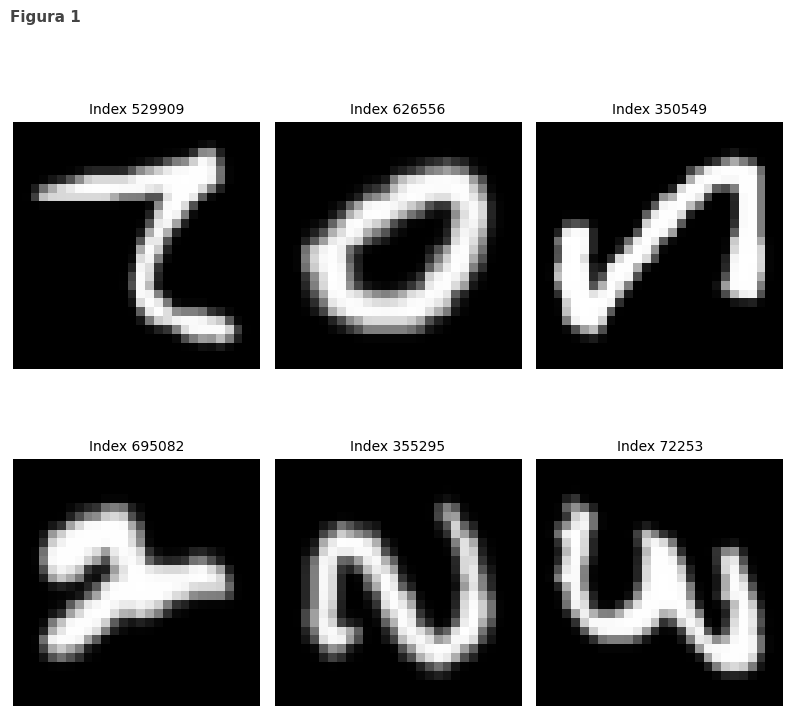

In [6]:
plot_random_images(X_images, image_shape=(28, 28), n=6, fig_num=fig_num)

In [7]:
X_images = X_images.reshape(X_images.shape[0], -1) # Flatten X_images

In [8]:
output_dim = np.unique(y_images).size
print("Cantidad de clases:", output_dim)

Cantidad de clases: 47


In [9]:
input_dim = X_images.shape[1]
print("Cantidad de features:", input_dim)

Cantidad de features: 784


In [10]:
rows = X_images.shape[0]
print("Cantidad de muestras:", rows)

Cantidad de muestras: 809555


Normalizo el dataset dividiendo por 255 así el máximo es 1.

Luego:

Dividir en Train, Validation y Test
- Dev 0.9, Test 0.1
- Train 7/9 de Dev, Val 2/9 de Dev

Sobre el dataset total:
- Train 0.7, Val 0.2, Test 0.1

In [11]:
X_images = scaler(X_images)

# Stratified split
X_dev, X_test, y_dev, y_test = stratified_split(X_images, y_images, frac=0.9)
del X_images
del y_images

X_train, X_val, y_train, y_val = stratified_split(X_dev, y_dev, frac=7/9)

Total de épocas para los modelos a evaluar

In [12]:
total_epochs = 300

<h2 style="color: #1976D2; font-weight: 500">
    2. Implementación y Entrenamiento de una Red Neuronal Básica
</h2>

Incisos **a** y **b** en `src/models/`

<h3 style="color: #00B0FF; font-weight: 400">
    Modelo M0
</h3>

- 1ra capa oculta:
    - 128 nodos con activación ReLU
- 2da capa oculta:
    - 64 nodos con activación ReLU
- Capa de salida:
    - 47 nodos con activación SoftMax

In [13]:
layers_m0 = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

lr_m0 = 0.35

m0 = SecuentialNeuralNetwork(
    layers_m0, 
    GradientDescent(learning_rate=lr_m0), 
    CrossEntropy()
)

m0_test = deepcopy(m0)

**Entrenamiento del modelo**

In [14]:
last_epoch_m0 = m0.fit(X=X_train, y=y_train, epochs=total_epochs, batch_size=None, X_val=X_val, y_val=y_val, early_stopping=None)

Training: 100%|██████████| 300/300 [1:04:01<00:00, 12.81s/ep]


**Evolución de la función de costo**

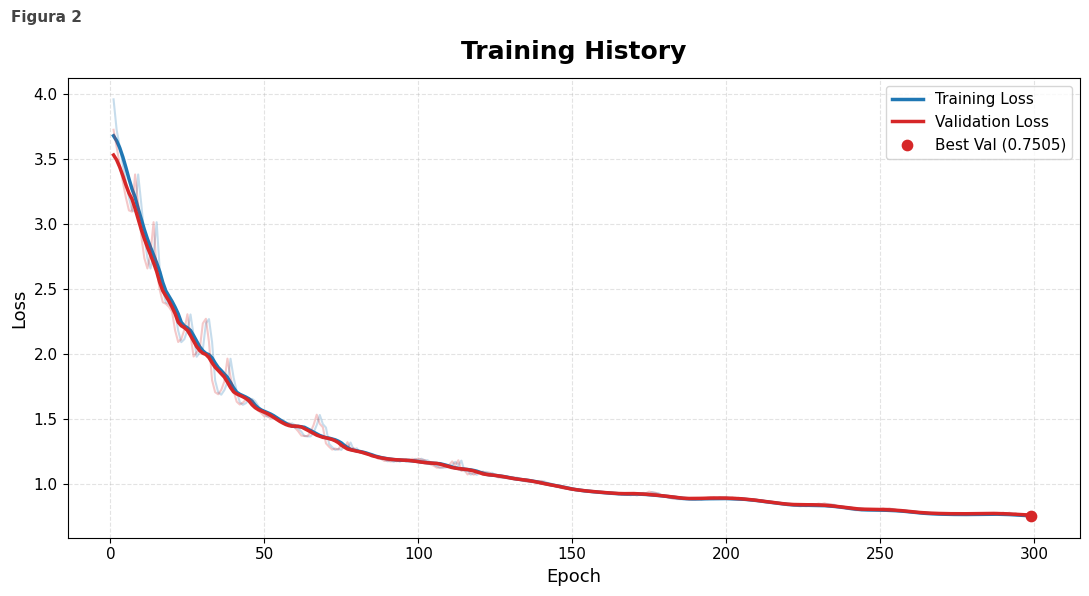

In [15]:
plot_training_history(m0.train_loss, m0.val_loss, fig_num=fig_num)

**Métricas de performance**

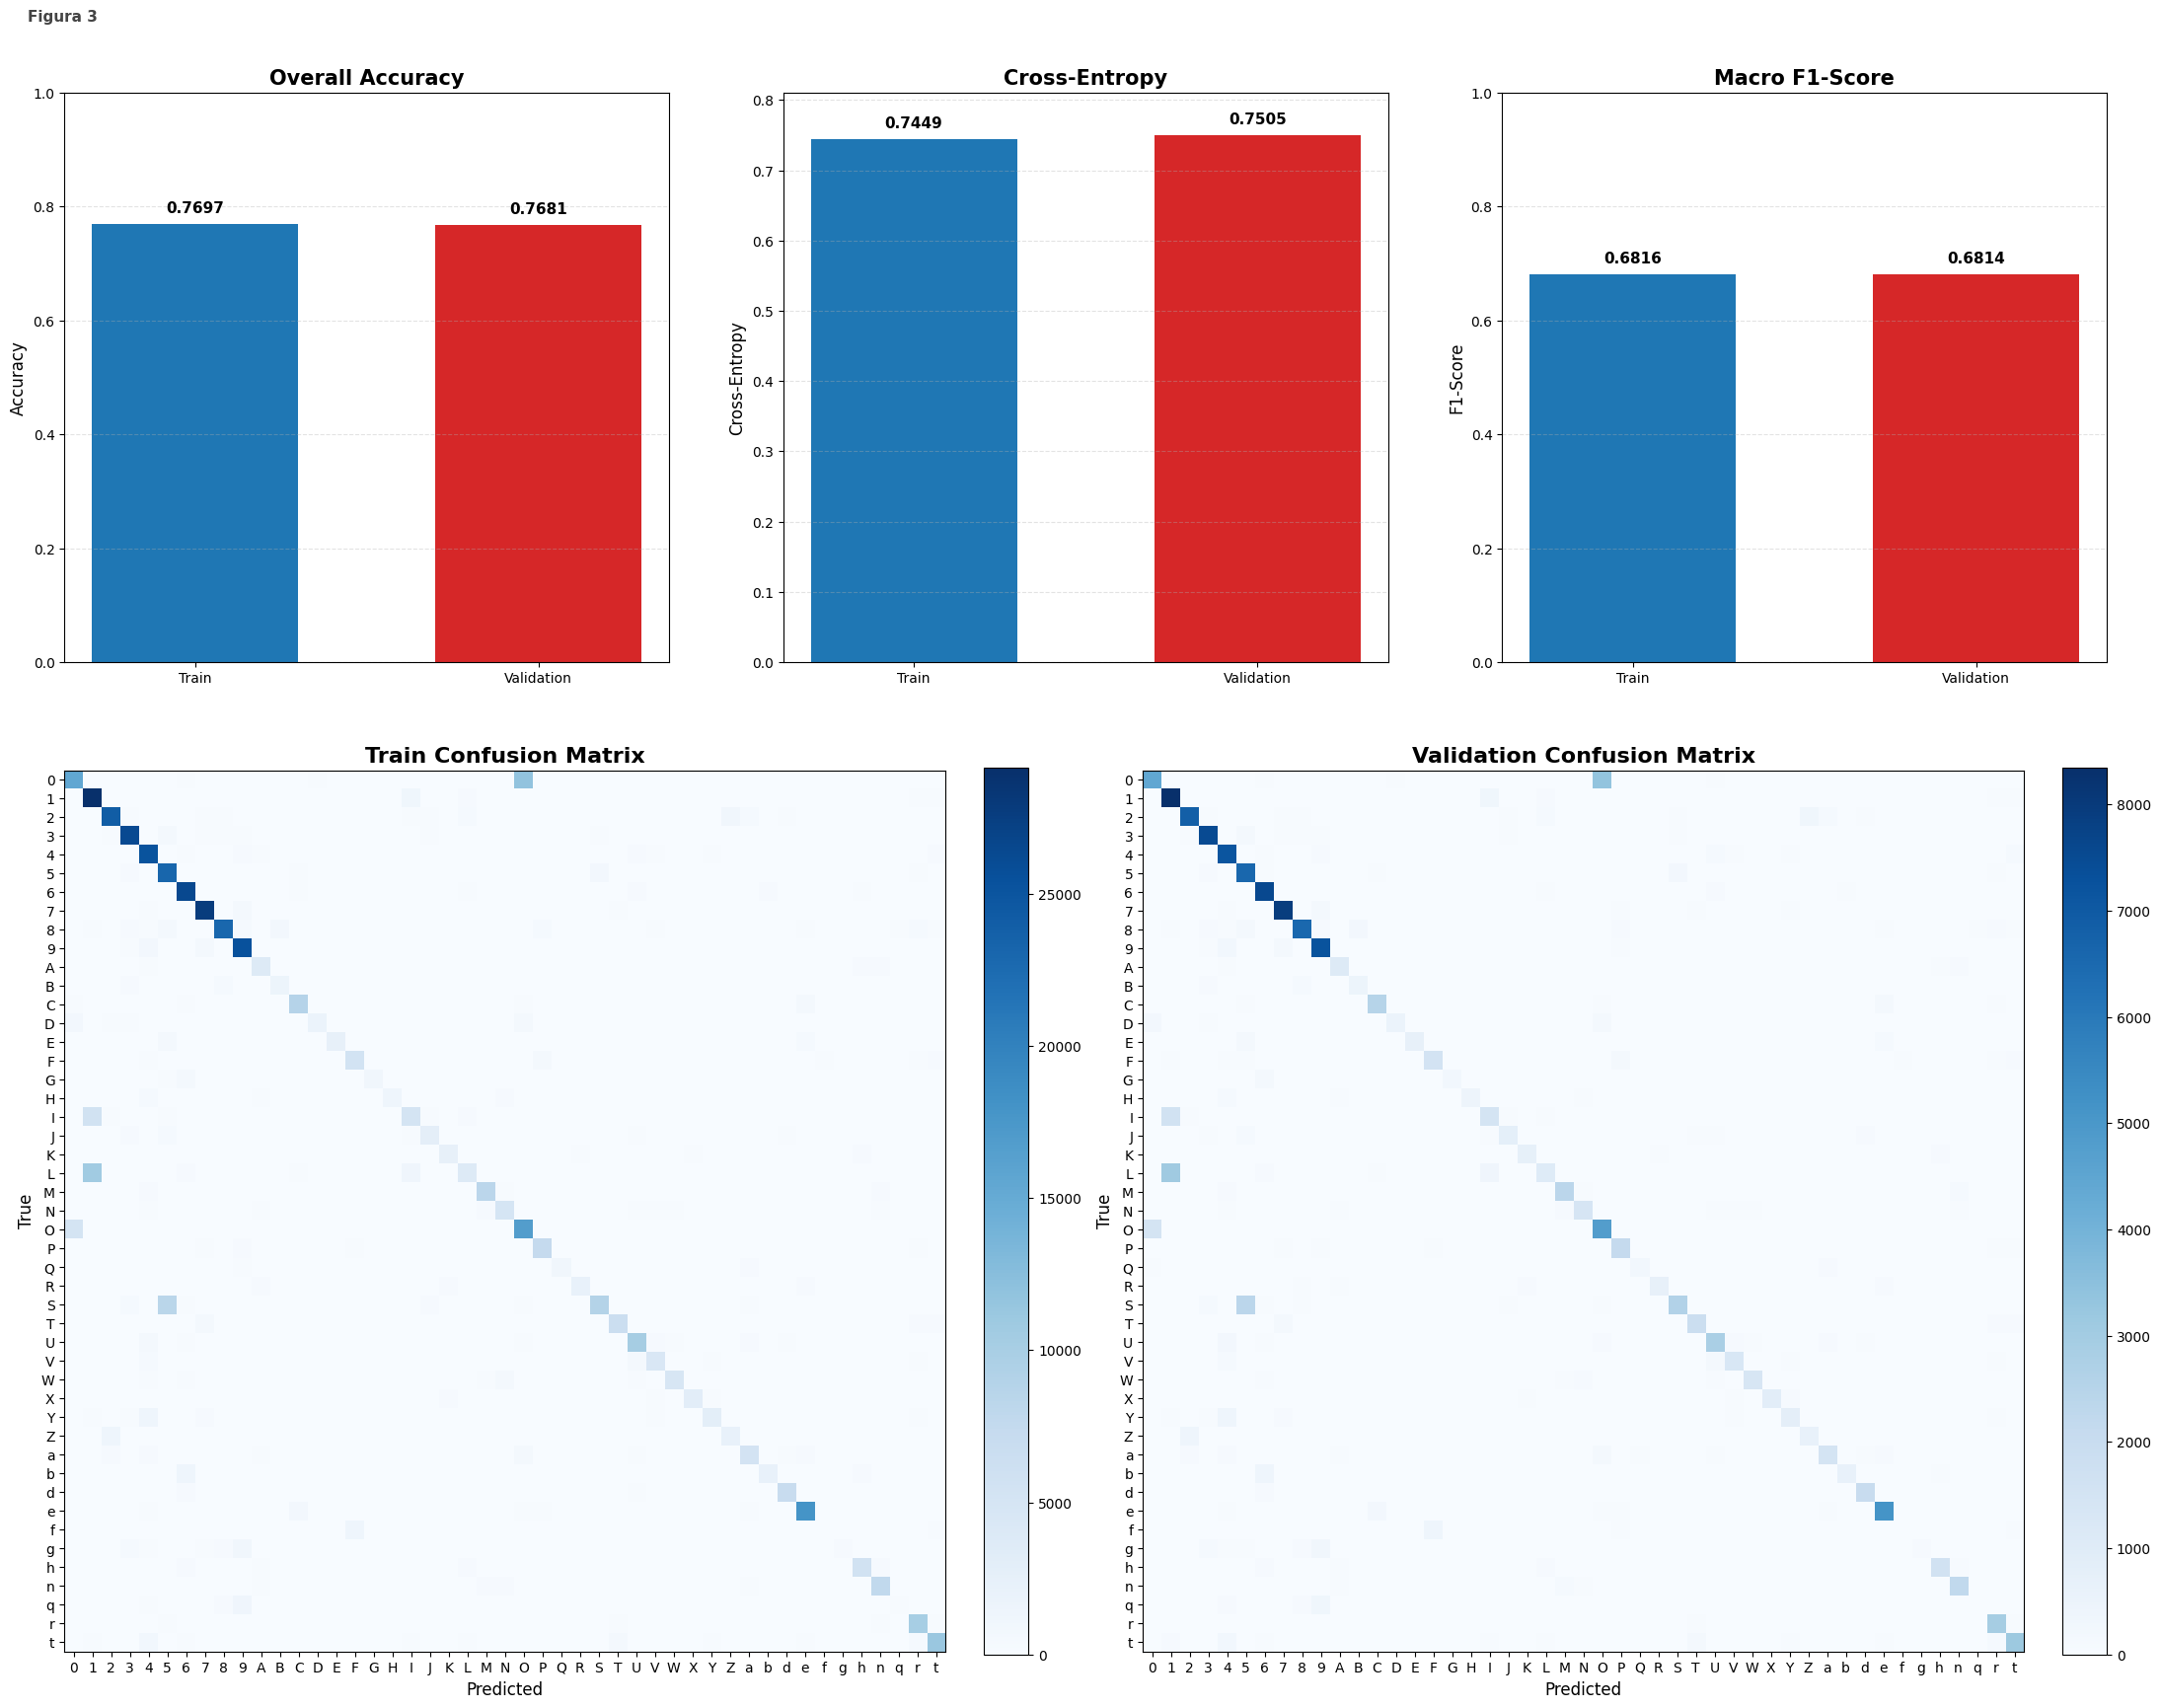

In [16]:
evaluate_model(m0, X_train, y_train, X_val, y_val, fig_num=fig_num)

<h2 style="color: #1976D2; font-weight: 500">
    3. Implementación y Entrenamiento de una Red Neuronal Avanzada
</h2>

<h3 style="color: #00B0FF; font-weight: 400">
    Mejoras al algoritmo de entrenamiento y reporte de los efectos observados sobre el tiempo de entrenamiento y la performance del modelo resultante
</h3>

**Implementaciones:**
- **Épocas a evaluar:** 75
- **Tamaño del dataset:** se utiliza el 30% del tamaño original de los conjuntos de train y validation, seleccionado aleatoriamente. Para EMNIST ByMerge, esto corresponde aproximadamente a 170k muestras de train y 48k de validation. Esta decisión se toma porque el objetivo no es alcanzar la máxima performance posible sobre el dataset completo, sino comparar la variación en tiempo de entrenamiento y desempeño al aplicar distintas mejoras de manera aislada.
- **Diseño a utilizar:**
    - 1ra capa oculta:
        - 128 nodos con activación ReLU
    - 2da capa oculta:
        - 64 nodos con activación ReLU
    - Capa de salida:
        - 47 nodos con activación SoftMax

In [17]:
epochs_test = 75

search_train_size = int(min(X_train.shape[0]*0.3, X_train.shape[0]))
search_val_size = int(min(X_val.shape[0]*0.3, X_val.shape[0]))

rng = np.random.default_rng(42)

search_train_idx = rng.choice(X_train.shape[0], size=search_train_size, replace=False)
search_val_idx = rng.choice(X_val.shape[0], size=search_val_size, replace=False)

X_train_search = X_train[search_train_idx]
y_train_search = y_train[search_train_idx]
X_val_search = X_val[search_val_idx]
y_val_search = y_val[search_val_idx]

- **Rate scheduling lineal (con saturación)**

In [18]:
linear_scheduling = {"type": "linear", "lr_min": 0.001, "k": 0.01}

layers_m_linsche = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_linsche = SecuentialNeuralNetwork(
    layers_m_linsche, 
    GradientDescent(learning_rate=0.01, scheduling=linear_scheduling), 
    CrossEntropy()
)

In [19]:
_ = m_linsche.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 75/75 [01:13<00:00,  1.01ep/s]


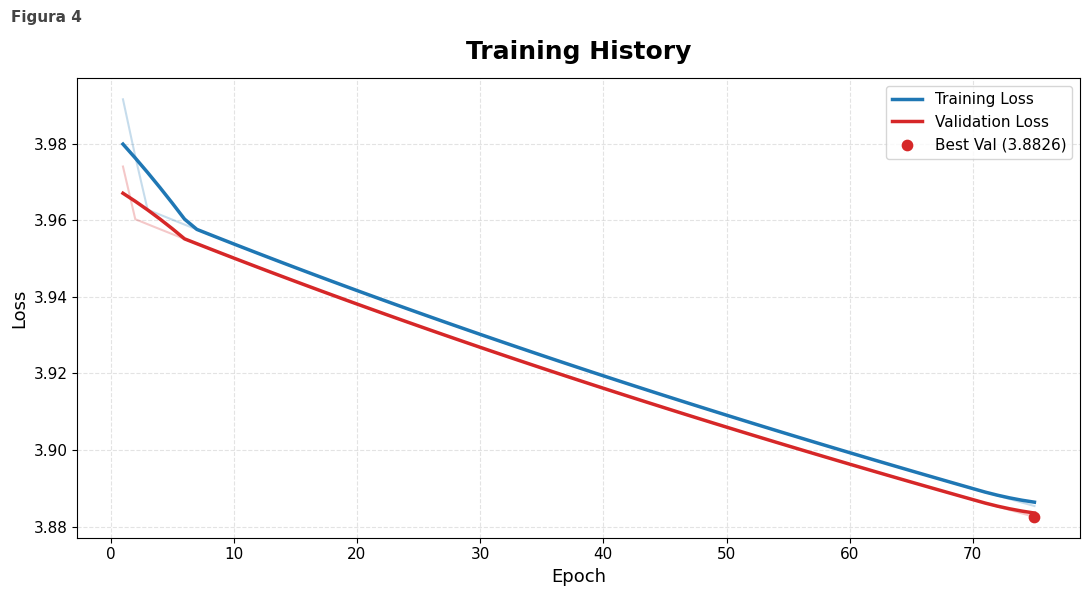

In [20]:
plot_training_history(m_linsche.train_loss, m_linsche.val_loss, fig_num=fig_num)

Se observa que incorporar linear scheduling sin otras mejoras empeora el entrenamiento del modelo en esta configuración. Una posible explicación es que la tasa de aprendizaje disminuye progresivamente, haciendo que las actualizaciones de los parámetros sean cada vez más pequeñas y pudiendo ralentizar la convergencia antes de alcanzar una buena solución.

- **Rate scheduling exponencial**

In [21]:
exponential_scheduling = {"type": "exponential", "gamma": 0.9}

layers_m_expsche = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_expsche = SecuentialNeuralNetwork(
    layers_m_expsche, 
    GradientDescent(learning_rate=0.01, scheduling=exponential_scheduling), 
    CrossEntropy()
)

In [22]:
_ = m_expsche.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 75/75 [01:20<00:00,  1.08s/ep]


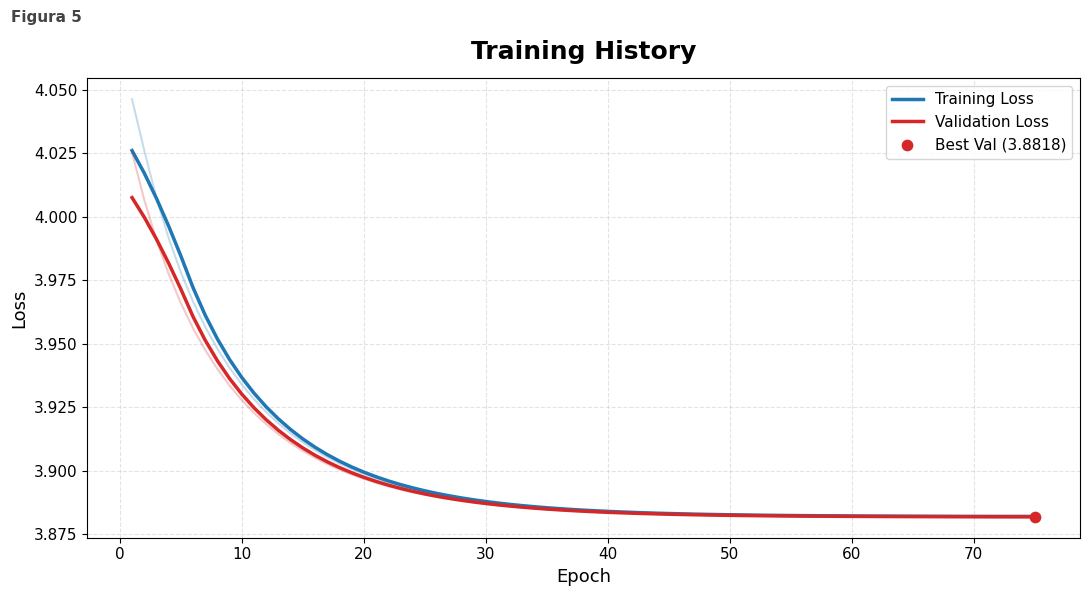

In [23]:
plot_training_history(m_expsche.train_loss, m_expsche.val_loss, fig_num=fig_num)

Al incorporar exponential scheduling, se observó una evolución más curva en el historial de entrenamiento, consistente con una disminución no lineal de la tasa de aprendizaje. Sin embargo, de forma aislada no representó una mejora significativa en el desempeño. Al igual que con linear scheduling, su aplicación sin combinarse con otras técnicas de optimización resultó poco efectiva e incluso potencialmente perjudicial en esta configuración experimental.

- **Mini-batch gradient descent**

In [24]:
layers_m_batch = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_batch = SecuentialNeuralNetwork(
    layers_m_batch, 
    GradientDescent(learning_rate=0.01), 
    CrossEntropy()
)

In [25]:
_ = m_batch.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=128, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 75/75 [01:26<00:00,  1.15s/ep]


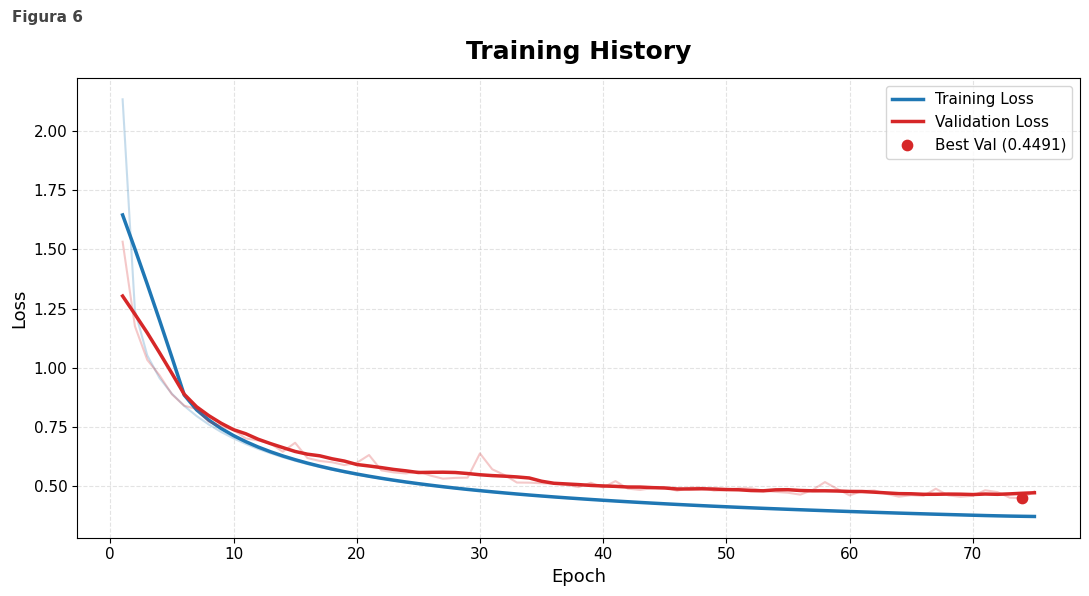

In [26]:
plot_training_history(m_batch.train_loss, m_batch.val_loss, fig_num=fig_num)

Tras incorporar mini-batches, se observa la primera mejora significativa en el tiempo necesario para alcanzar el mejor valor de validation loss. La loss cae de manera pronunciada hasta aproximadamente la época 10 y, a partir de ese punto, el error de validación tiende a estabilizarse. Esta mejora indica que el uso de mini-batches acelera el entrenamiento respecto del gradiente descendente estándar, manteniendo una evolución estable de la loss de validación luego de las primeras épocas.

- **Optimizador Adam**

In [27]:
layers_m_adam = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_adam = SecuentialNeuralNetwork(
    layers_m_adam, 
    ADAM(), 
    CrossEntropy()
)

In [28]:
_ = m_adam.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=None)

Training: 100%|██████████| 75/75 [01:36<00:00,  1.28s/ep]


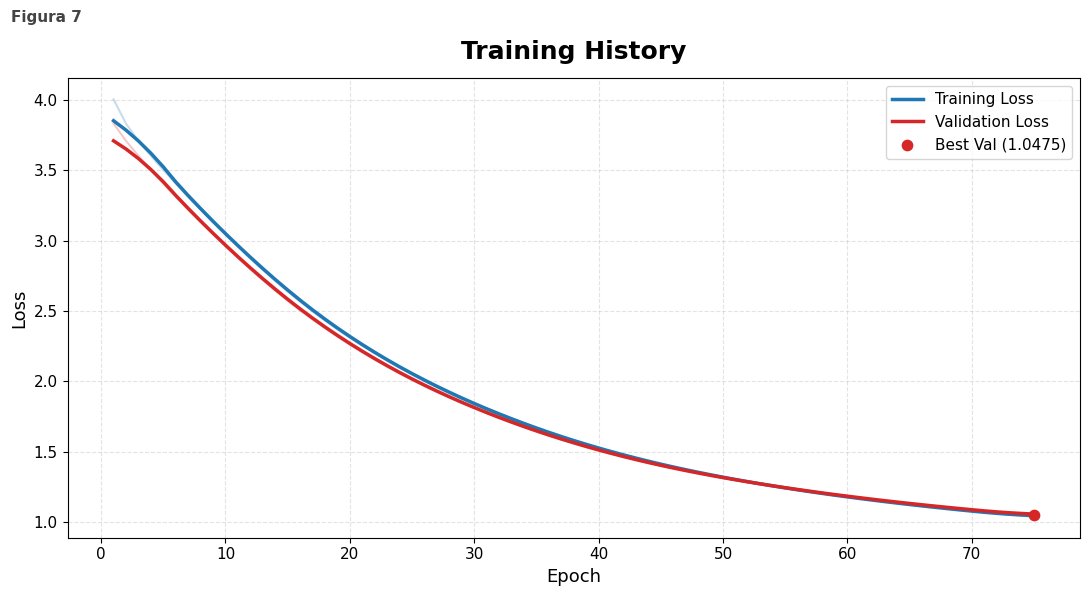

In [29]:
plot_training_history(m_adam.train_loss, m_adam.val_loss, fig_num=fig_num)

Tras la implementación de Adam, se observa una convergencia significativamente más rápida y estable en comparación con Gradient Descent estándar. La función de pérdida presenta una disminución sostenida tanto en training como en validation a lo largo de las épocas, alcanzando valores considerablemente menores que los obtenidos con GD crudo.

- **Regularización (L2, Early Stopping)**

In [30]:
l2_reg = 0.01

layers_m_reg = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=l2_reg),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=l2_reg),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=l2_reg)
]

m_reg = SecuentialNeuralNetwork(
    layers_m_reg, 
    GradientDescent(learning_rate=0.01), 
    CrossEntropy()
)

In [31]:
_ = m_reg.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search, early_stopping=10)

Training: 100%|██████████| 75/75 [02:31<00:00,  2.02s/ep]


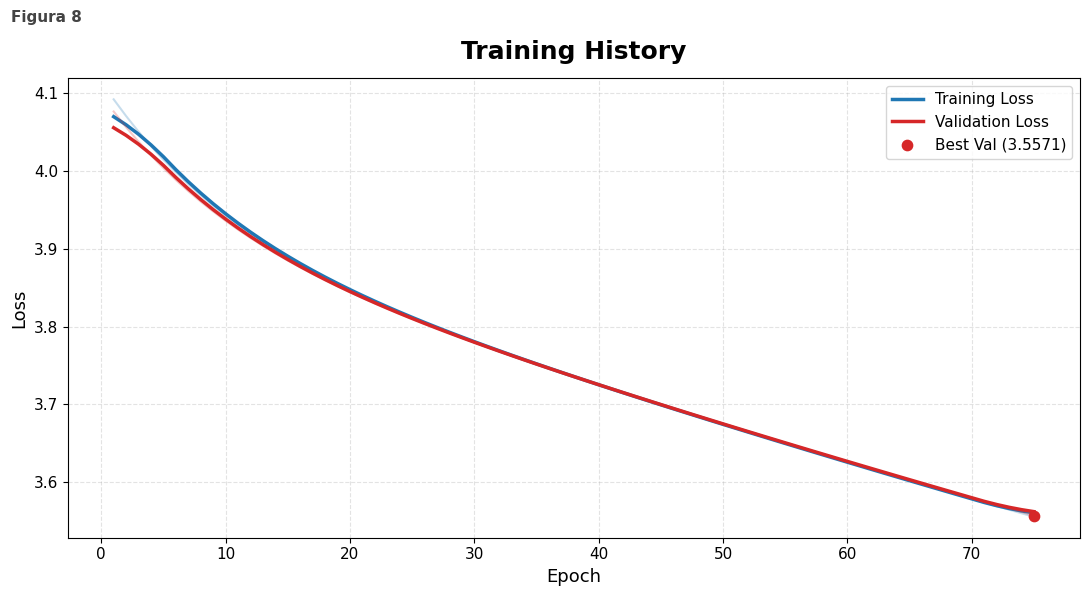

In [32]:
plot_training_history(m_reg.train_loss, m_reg.val_loss, fig_num=fig_num)

Bajo la configuración actual, agregarle una regularización L2 no afecta de manera significativa al modelo, principalmente porque no se llegó a la convergencia en entrenamiento. Se puede ver cómo ambas curvas descienden muy cerca una de la otra, lo que indica que no hay overfitting visible. De manera similar, el mecanismo de early stopping no tuvo efecto, ya que su activación requiere un estancamiento o deterioro en la pérdida de validación, lo cual no ocurrió dado que la validation loss continuó disminuyendo de forma sostenida.

* **Label Smoothing**

In [33]:
layers_m_lsmoothing = [
    DenseLayer(
        input_dim=input_dim,
        output_dim=128,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=128,
        output_dim=64,
        activation=ReLU(),
        l2_regularization=0.),
    DenseLayer(
        input_dim=64,
        output_dim=output_dim,
        activation=SoftMax(),
        l2_regularization=0.)
]

m_lsmoothing = SecuentialNeuralNetwork(
    layers_m_lsmoothing, 
    GradientDescent(learning_rate=0.01), 
    CrossEntropy(smoothing=0.1)
)

In [34]:
_ = m_lsmoothing.fit(X=X_train_search, y=y_train_search, epochs=epochs_test, batch_size=None, X_val=X_val_search, y_val=y_val_search)

Training: 100%|██████████| 75/75 [02:44<00:00,  2.20s/ep]


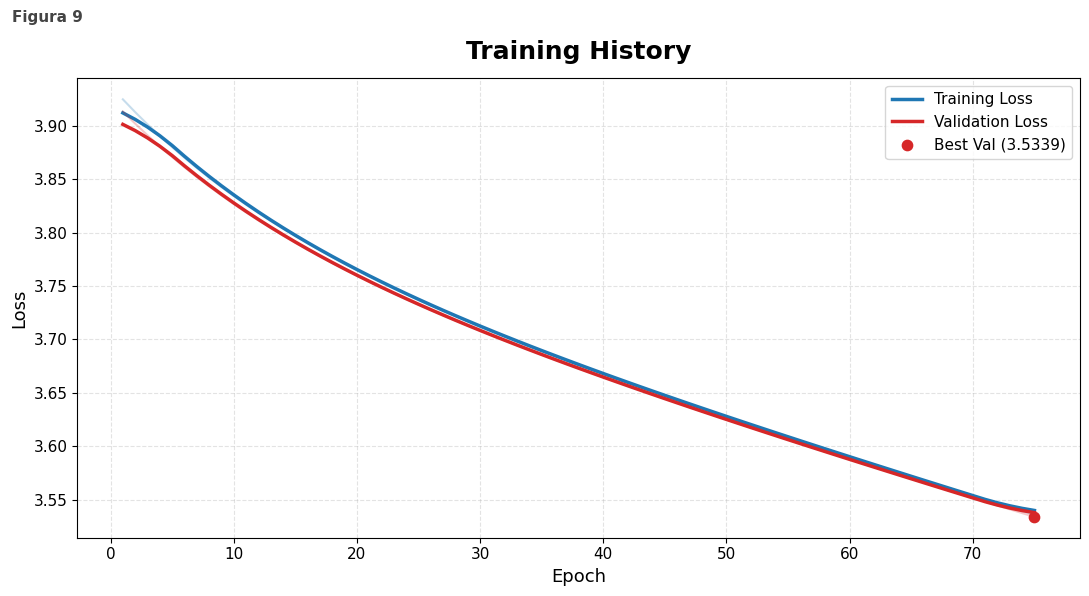

In [35]:
plot_training_history(m_lsmoothing.train_loss, m_lsmoothing.val_loss, fig_num=fig_num)

La mejora de label smoothing no parece que haya hecho ningún cambio si se aplica de manera aislada sobre el modelo base.

---

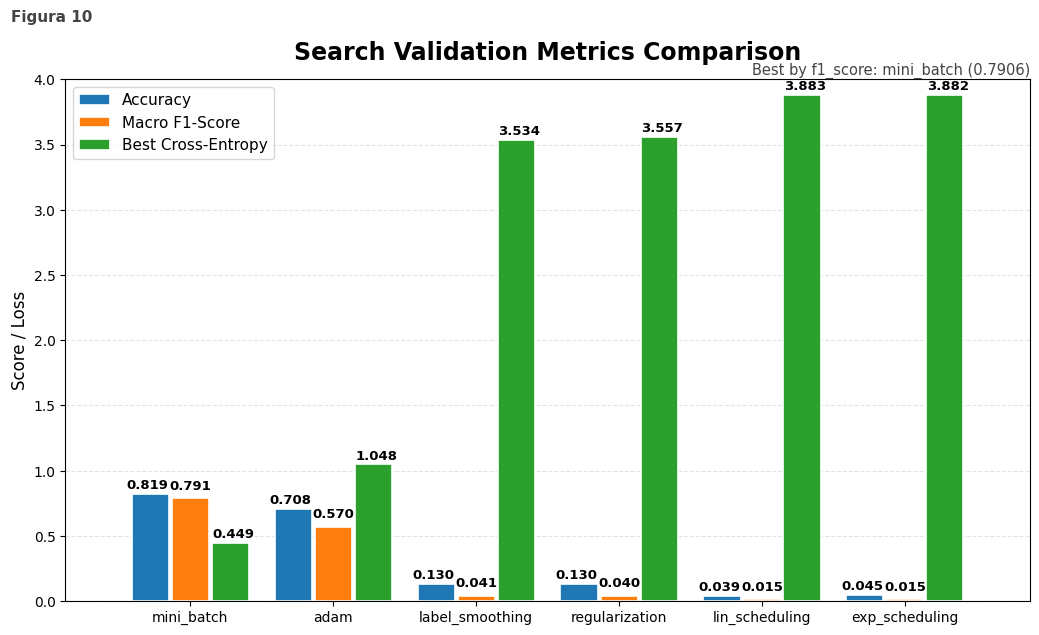

In [36]:
models = {
    "lin_scheduling": m_linsche,
    "exp_scheduling": m_expsche,
    "mini_batch": m_batch,
    "adam": m_adam,
    "regularization": m_reg,
    "label_smoothing": m_lsmoothing
}

plot_model_metric_comparison(models, X_val_search, y_val_search, split_name="Search Validation", fig_num=fig_num)

**Análisis:**

- `Linear Scheduling:` Esta configuración no mostró una mejora respecto del modelo base. La reducción progresiva de la learning rate hace que, luego de las primeras épocas, las actualizaciones sean cada vez más pequeñas, lo que ralentiza el aprendizaje antes de alcanzar una buena solución. Como resultado, la convergencia fue más lenta y la performance final fue muy baja.

- `Exponential Scheduling:` Produjo una dinámica de entrenamiento más suave que el linear scheduling, con una caída más gradual de la función de costo. Sin embargo, aplicado de manera aislada tampoco logró una mejora significativa en la performance. En este experimento, reducir la learning rate de forma exponencial no fue suficiente para compensar las limitaciones del entrenamiento base y la convergencia y la performance fue muy similiar al Linear Scheduling.

- `Mini Batch Gradient Descent:` Fue la primera mejora positiva. Al actualizar los parámetros usando batches en lugar del conjunto completo, se redujo el costo computacional por época y se aceleró la convergencia. Además, la validation loss descendió rápidamente en las primeras épocas y luego se estabilizó, mostrando un entrenamiento más eficiente sin pérdida de estabilidad.

- `Adam:` Fue una de las mejoras más efectivas junto con Mini Batch Gradient Descent. Permitió una convergencia más rápida y estable que gradient descent estándar. Tanto la training loss como la validation loss disminuyeron de forma sostenida, alcanzando mejores valores en menos tiempo.

- `Label Smoothing:` Aplicado de manera aislada no produjo mejoras visibles en esta configuración. La evolución de las curvas de entrenamiento y validación fue muy similar a la del modelo base, por lo que su efecto sobre la generalización resultó casi nulo. Esto sugiere que, para este experimento, no fue una técnica determinante por sí sola.

**Nota:**

Solo las mejoras de Mini Batch Gradient Descent y Adam consiguieron convergencia en 75 épocas. Sin embargo, si se combinan las técnicas, se pueden alcanzar mejores resultados que al aplicarlas por separado.

---

<h3 style="color: #00B0FF; font-weight: 400">
    Random Grid Search para M1
</h3>

**Decisiones de diseño:**
- **Épocas:** 50
- **Early stopping:** 3
- **Cantidad de modelos a explorar:** 30
- **Tamaño del dataset:** se utiliza el 30% del tamaño original de los conjuntos de train y validation, seleccionado aleatoriamente. Para EMNIST ByMerge, esto corresponde aproximadamente a 170k muestras de train y 48k de validation. El objetivo es evaluar una variedad amplia de configuraciones sin elevar excesivamente el costo computacional.

Las configuraciones a explorar son las siguientes:

```python
possible_configs = {
    "layers": [
        (128, 64),
        (256, 128),
        (256, 128, 64),
    ],
    "l2": [0.0, 1e-5, 1e-3],
    "batch_size": [128, 256],
    "scheduling": [
        None,
        {"type": "exponential", "gamma": 0.99},
    ],
    "label_smoothing": [0.0, 0.05],
    "lr": [5e-4, 1e-3, 5e-3],
}
```

In [37]:
possible_configs = {
    "layers": [
        (128, 64), 
        (256, 128),
        (256, 128, 64)],
    "l2": [0., 1e-5, 1e-3],
    "batch_size": [128, 256],
    "scheduling": [
        None, 
        {"type": "exponential", "gamma": 0.99}],
    "label_smoothing": [0., 0.05],
    "lr": [5e-4, 1e-3, 5e-3],
}

epochs_search = 50
early_stopping = 3
K_models = 30

models, model_configs = random_grid_search_custom(input_dim, output_dim, X_train_search, 
    y_train_search, X_val_search, y_val_search, epochs_search, K_models, 
    possible_configs, early_stopping)

100%|██████████| 30/30 [20:40<00:00, 41.33s/it]


In [38]:
display(compare_models(models, list(model_configs.keys())).style.hide(axis="index"))

Model,Best Val Loss,Best Train Loss,Best Epoch,Final Train Loss,Final Val Loss,Epochs Trained
0,0.406533,0.308259,9,0.275845,0.410381,12
10,0.407500,0.298378,9,0.288246,0.419555,10
8,0.409147,0.373192,30,0.372228,0.415121,33
21,0.411061,0.287630,10,0.256806,0.439497,13
16,0.412970,0.269957,13,0.269957,0.412970,13
9,0.416310,0.292420,13,0.284811,0.424250,14
13,0.418583,0.389645,9,0.375802,0.423815,12
5,0.434496,0.350464,12,0.329684,0.443462,15
14,0.436068,0.334693,23,0.324742,0.436573,26
23,0.436168,0.400934,28,0.400934,0.436168,28


Display de la mejor configuración

In [39]:
config_m1 = get_best_config(models, model_configs)

display(dict(config_m1))

{'layers': (256, 128, 64),
 'l2': 0.0,
 'batch_size': 128,
 'scheduling': {'type': 'exponential', 'gamma': 0.99},
 'label_smoothing': 0.0,
 'lr': 0.0005}

<h3 style="color: #00B0FF; font-weight: 400">
    Modelo M1
</h3>

In [40]:
m1 = SecuentialNeuralNetwork.build_from_config(input_dim, output_dim, ReLU, 
    SoftMax, config_m1, ADAM, CrossEntropy)

m1_test = deepcopy(m1)

In [41]:
last_epoch_m1 = m1.fit(X_train, y_train, epochs=total_epochs, batch_size=config_m1["batch_size"], 
    X_val=X_val, y_val=y_val, early_stopping=early_stopping)

Training:   4%|▎         | 11/300 [04:10<1:49:33, 22.75s/ep]

Early stopping after epoch: 11


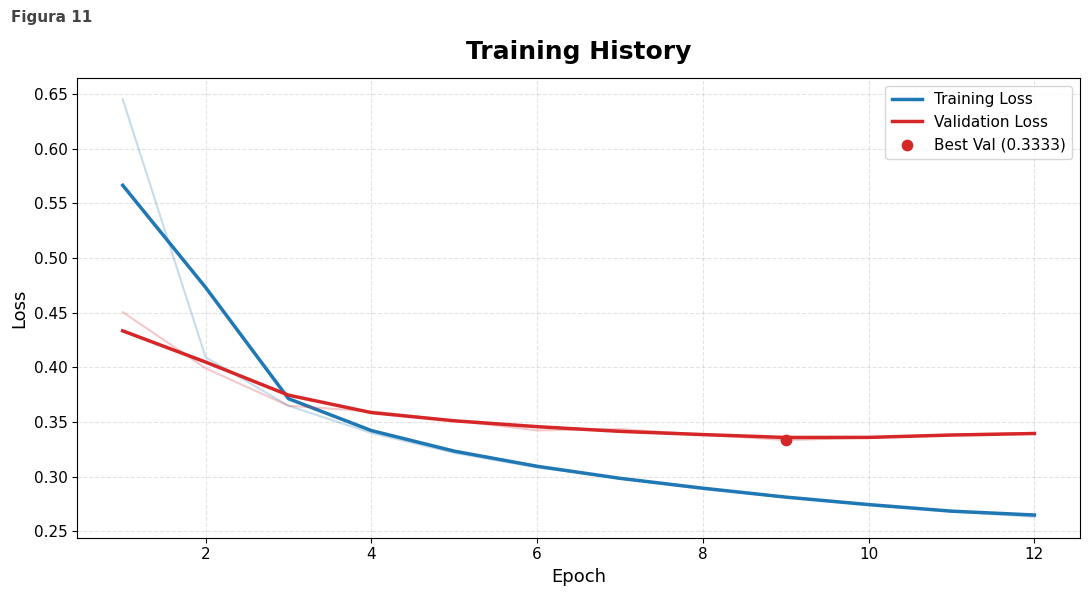

In [42]:
plot_training_history(m1.train_loss, m1.val_loss, fig_num=fig_num)

Métricas

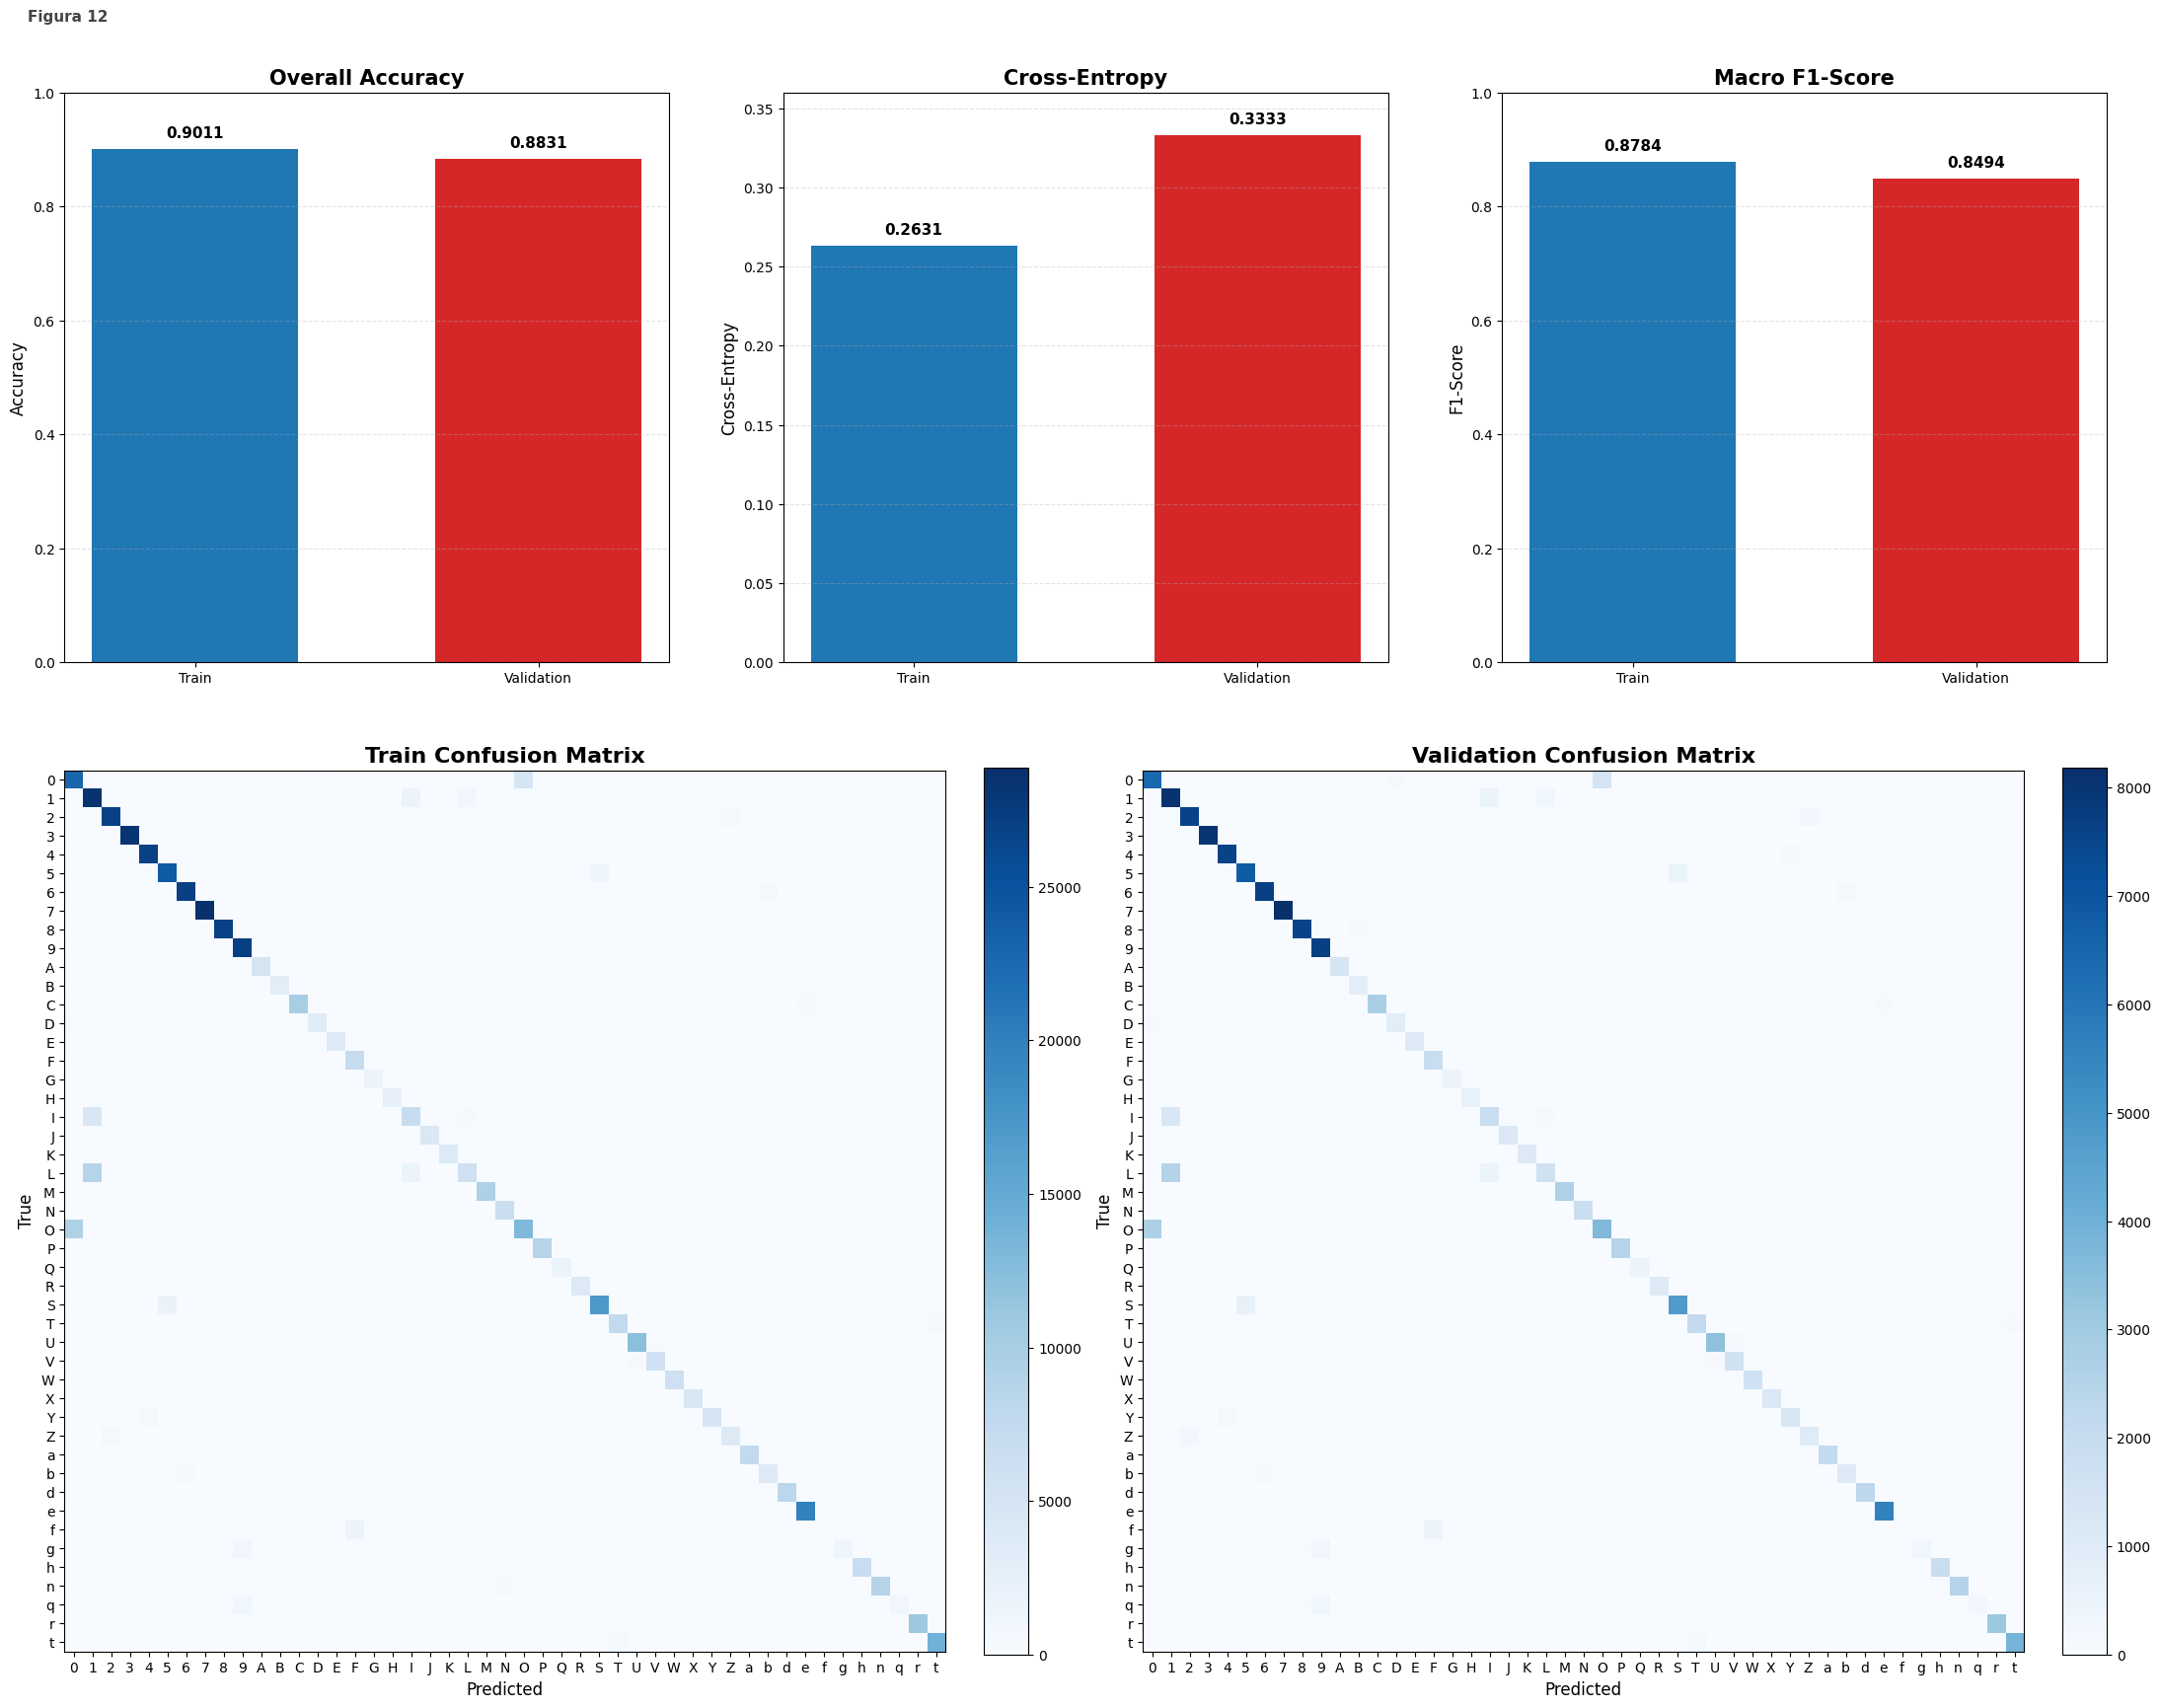

In [43]:
evaluate_model(m1, X_train, y_train, X_val, y_val, fig_num=fig_num)

<h2 style="color: #1976D2; font-weight: 500">
    4. Desarrollo de una Red Neuronal con PyTorch
</h2>

Device y Dataset

In [44]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).long()

X_val_tensor = torch.from_numpy(X_val).float()
y_val_tensor = torch.from_numpy(y_val).long()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

Using mps device


<h3 style="color: #00B0FF; font-weight: 400">
    Modelo M2
</h3>

In [45]:
config_m2 = config_m1
m2 = MLP(input_dim, config_m2["layers"], output_dim, dropout=0., activation=nn.ReLU)
optimizer_m2 = torch.optim.Adam(m2.parameters(), lr=config_m2["lr"], weight_decay=config_m2["l2"])
loss_fn_m2 = torch.nn.CrossEntropyLoss(label_smoothing=config_m2["label_smoothing"])

train_loader_m2 = DataLoader(
    train_dataset,
    batch_size=config_m2["batch_size"],
    shuffle=True,
    drop_last=True
)

val_loader_m2 = DataLoader(
    val_dataset,
    batch_size=config_m2["batch_size"],
    shuffle=False
)

m2_test = deepcopy(m2)

Training

In [46]:
m2 = m2.to(device)

train_loss, val_loss, last_epoch_m2 = train_and_eval(train_loader_m2, val_loader_m2, m2, loss_fn_m2, 
    optimizer_m2, device, total_epochs, early_stopping, config_m2["scheduling"])

  3%|▎         | 10/300 [03:54<1:53:09, 23.41s/it]

Early stopping after epoch: 10


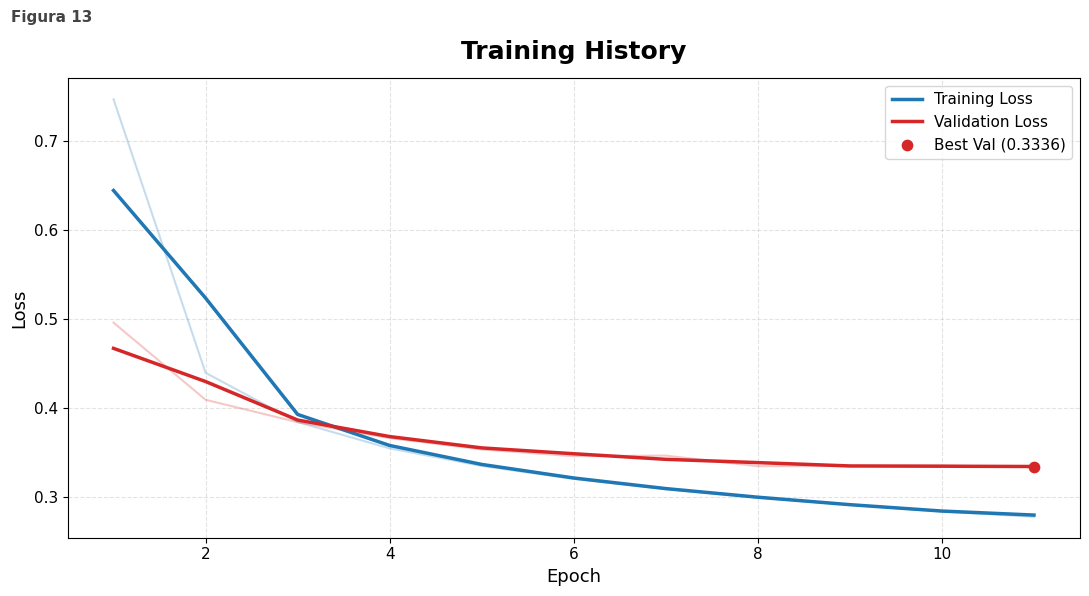

In [47]:
plot_training_history(train_loss, val_loss, fig_num=fig_num)

Métricas

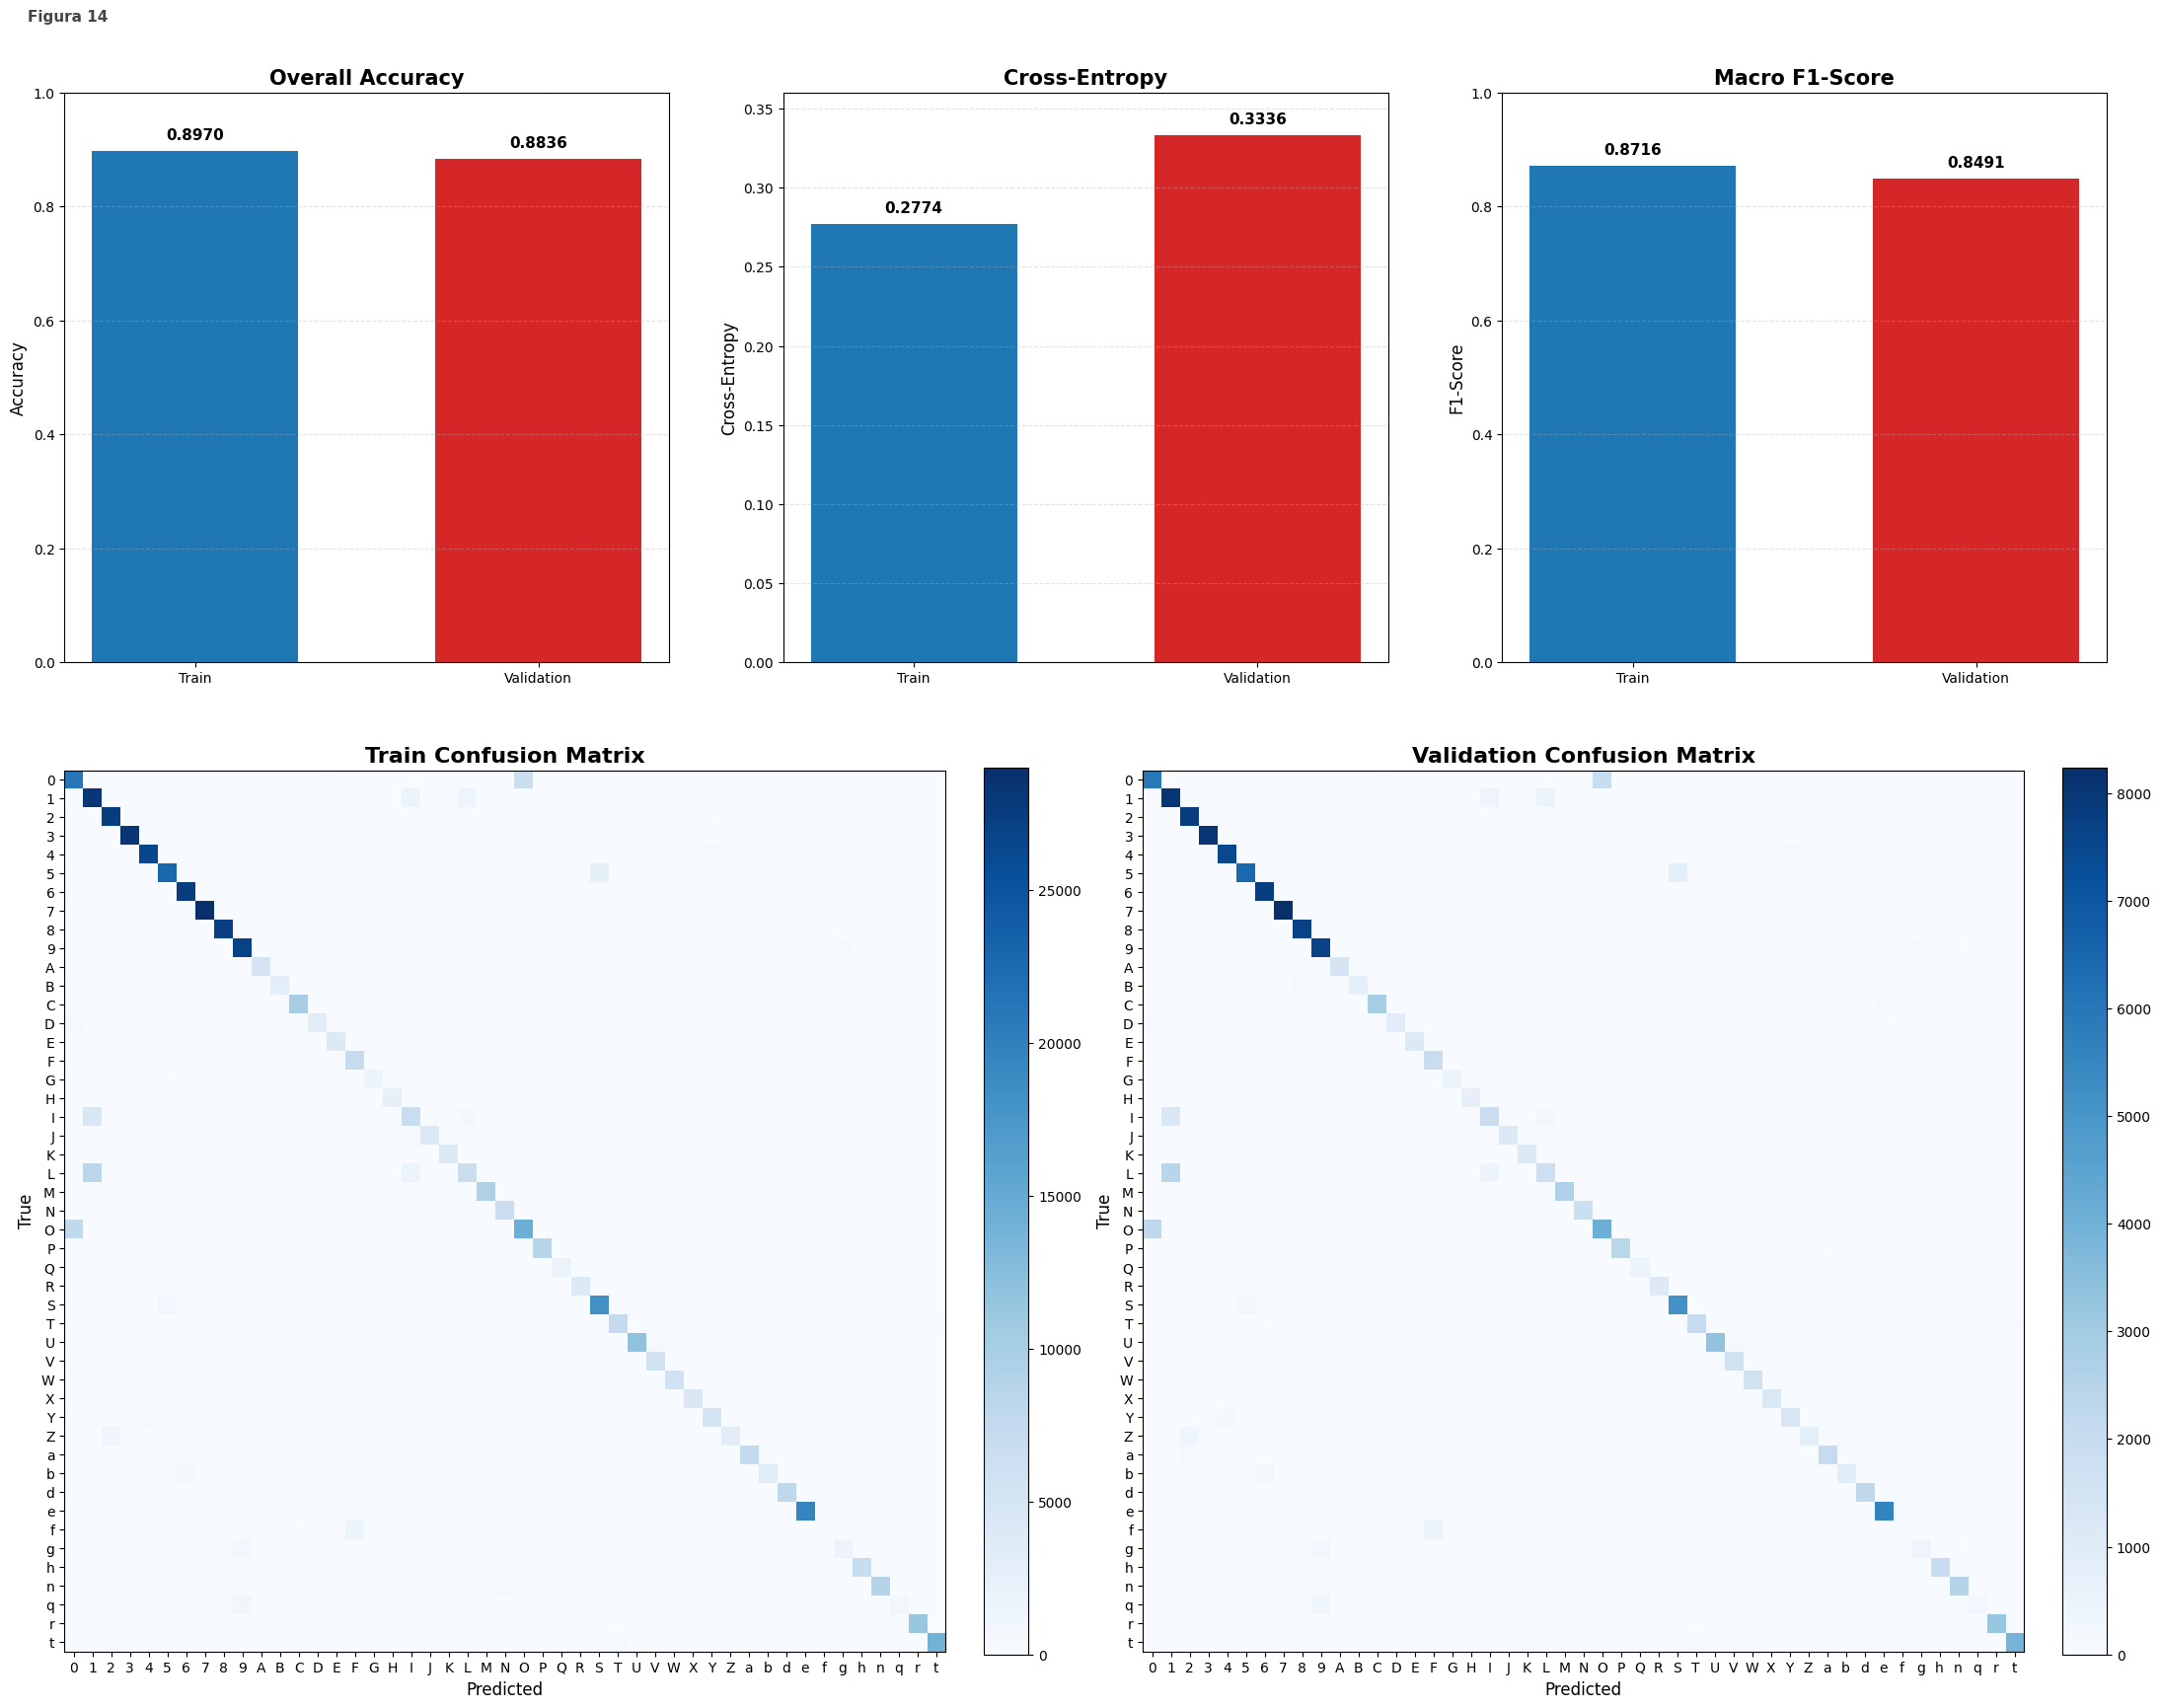

In [48]:
evaluate_model(
    m2, 
    X_train_tensor.detach().cpu().numpy(), 
    y_train_tensor.detach().cpu().numpy(), 
    X_val_tensor.detach().cpu().numpy(), 
    y_val_tensor.detach().cpu().numpy(),
    device=device, 
    fig_num=fig_num
)

<h3 style="color: #00B0FF; font-weight: 400">
    Comparación de modelos M1 y M2
</h3>

In [49]:
df = compare_models_table(m1, m2, X_train, y_train, X_val, y_val, device, fig_num)

cols = [c for c in df.T.columns if c != "model"]

display(df.T.style.format("{:.3f}", subset=cols))

model,model1,model2
train_acc,0.901,0.897
train_f1,0.878,0.872
train_cross_entropy,0.263,0.281
val_acc,0.883,0.884
val_f1,0.849,0.849
val_cross_entropy,0.333,0.334


Ambos modelos presentan métricas muy parecidas, lo que valida que los comportamientos de ambos modelos son el casi el mismo.

In [50]:
del X_train
del y_train
del X_val
del y_val



<h3 style="color: #00B0FF; font-weight: 400">
    Random Grid Search para M3
</h3>

**Decisiones de diseño:**
- **Épocas:** 50
- **Early stopping:** 3
- **Cantidad de modelos a explorar:** 30
- **Tamaño del dataset:** se utiliza el 30% del tamaño original de los conjuntos de train y validation, seleccionado aleatoriamente. Para EMNIST ByMerge, esto corresponde aproximadamente a 170k muestras de train y 48k de validation. El objetivo es evaluar una variedad amplia de configuraciones sin elevar excesivamente el costo computacional.

Las configuraciones a explorar son las siguientes:

```python
possible_configs = {
    "layers": [
        [128, 64],
        [256, 128],
        [512, 256],
        [512, 256, 128],
    ],
    "dropout": [0.0, 0.1, 0.2],
    "l2": [0.0, 1e-5],
    "batch_size": [64, 128, 256],
    "lr": [5e-4, 1e-3, 5e-3],
    "optimizer": [torch.optim.AdamW],
    "activation": [nn.ReLU, nn.LeakyReLU, nn.SiLU, nn.GELU],
    "batch_norm": [True, False],
    "scheduling": [
        None, 
        {"type": "exponential", "gamma": 0.99}],
    "label_smoothing": [0., 0.05],
}
```

In [51]:
X_train_search_tensor = torch.from_numpy(X_train_search).float()
y_train_search_tensor = torch.from_numpy(y_train_search).long()

X_val_search_tensor = torch.from_numpy(X_val_search).float()
y_val_search_tensor = torch.from_numpy(y_val_search).long()

del X_train_search
del y_train_search
del X_val_search
del y_val_search

train_search_dataset = TensorDataset(X_train_search_tensor, y_train_search_tensor)
val_search_dataset = TensorDataset(X_val_search_tensor, y_val_search_tensor)

possible_configs = {
    "layers": [
        [128, 64],
        [256, 128],
        [512, 256],
        [512, 256, 128],
    ],
    "dropout": [0.0, 0.1, 0.2],
    "l2": [0.0, 1e-5],
    "batch_size": [64, 128, 256],
    "lr": [5e-4, 1e-3, 5e-3],
    "optimizer": [torch.optim.AdamW],
    "activation": [nn.ReLU, nn.LeakyReLU, nn.SiLU, nn.GELU],
    "batch_norm": [True, False],
    "scheduling": [
        None, 
        {"type": "exponential", "gamma": 0.99}],
    "label_smoothing": [0., 0.05],
}

K_models = 30

In [52]:
models, model_configs = random_grid_search_torch(input_dim, output_dim, train_search_dataset, val_search_dataset, 
    epochs_search, K_models, possible_configs, early_stopping, device)

100%|██████████| 30/30 [50:31<00:00, 101.05s/it] 


In [53]:
display(compare_models(models, list(model_configs.keys())).style.hide(axis="index"))

Model,Best Val Loss,Best Train Loss,Best Epoch,Final Train Loss,Final Val Loss,Epochs Trained
16,0.341256,0.350062,12,0.332565,0.344384,15
12,0.347802,0.269494,12,0.269494,0.347802,12
24,0.352670,0.291612,9,0.266848,0.365686,12
10,0.354404,0.388548,17,0.384860,0.355409,18
11,0.359726,0.280898,13,0.280898,0.359726,13
14,0.364658,0.330495,6,0.288155,0.367587,9
4,0.372018,0.282197,6,0.268019,0.372424,7
17,0.373024,0.276233,6,0.235367,0.384354,9
3,0.383918,0.331647,10,0.314713,0.385431,13
29,0.384131,0.357253,8,0.333345,0.389378,11


Display de la mejor configuración

In [54]:
config_m3 = get_best_config(models, model_configs)

display(dict(config_m3))

{'layers': [512, 256, 128],
 'dropout': 0.2,
 'l2': 1e-05,
 'batch_size': 128,
 'lr': 0.005,
 'optimizer': torch.optim.adamw.AdamW,
 'activation': torch.nn.modules.activation.ReLU,
 'batch_norm': True,
 'scheduling': None,
 'label_smoothing': 0.0}

<h3 style="color: #00B0FF; font-weight: 400">
    Modelo M3
</h3>

In [55]:
m3 = MLP(input_dim, config_m3["layers"], output_dim, config_m3["dropout"], 
    config_m3["activation"], config_m3["batch_norm"])

train_loader_m3 = DataLoader(
    train_dataset,
    batch_size=config_m3["batch_size"],
    shuffle=True,
    drop_last=True
)

val_loader_m3 = DataLoader(
    val_dataset,
    batch_size=config_m3["batch_size"],
    shuffle=False
)

loss_fn_m3 = nn.CrossEntropyLoss(label_smoothing=config_m3["label_smoothing"])
optimizer_m3 = config_m3["optimizer"](m3.parameters(), lr=config_m3["lr"], weight_decay=config_m3["l2"])

m3_test = deepcopy(m3)

In [56]:
m3 = m3.to(device)

train_loss, val_loss, last_epoch_m3 = train_and_eval(train_loader_m3, val_loader_m3, m3, loss_fn_m3, 
    optimizer_m3, device, epochs=total_epochs, early_stopping=early_stopping, 
    scheduling=config_m3["scheduling"])

  8%|▊         | 25/300 [07:57<1:27:31, 19.10s/it]

Early stopping after epoch: 25


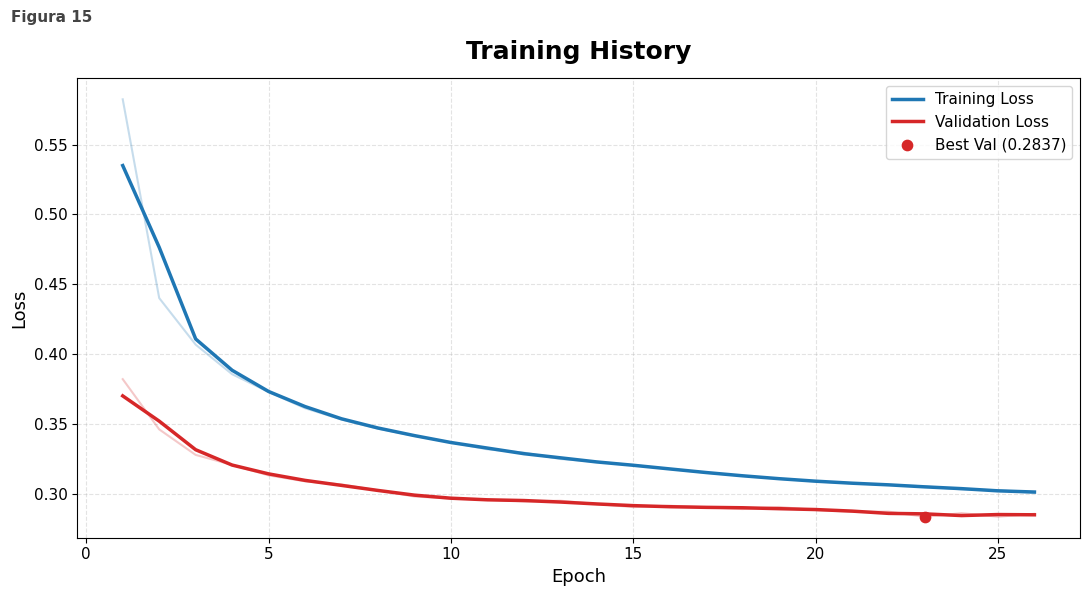

In [57]:
plot_training_history(train_loss, val_loss, fig_num=fig_num)

Métricas

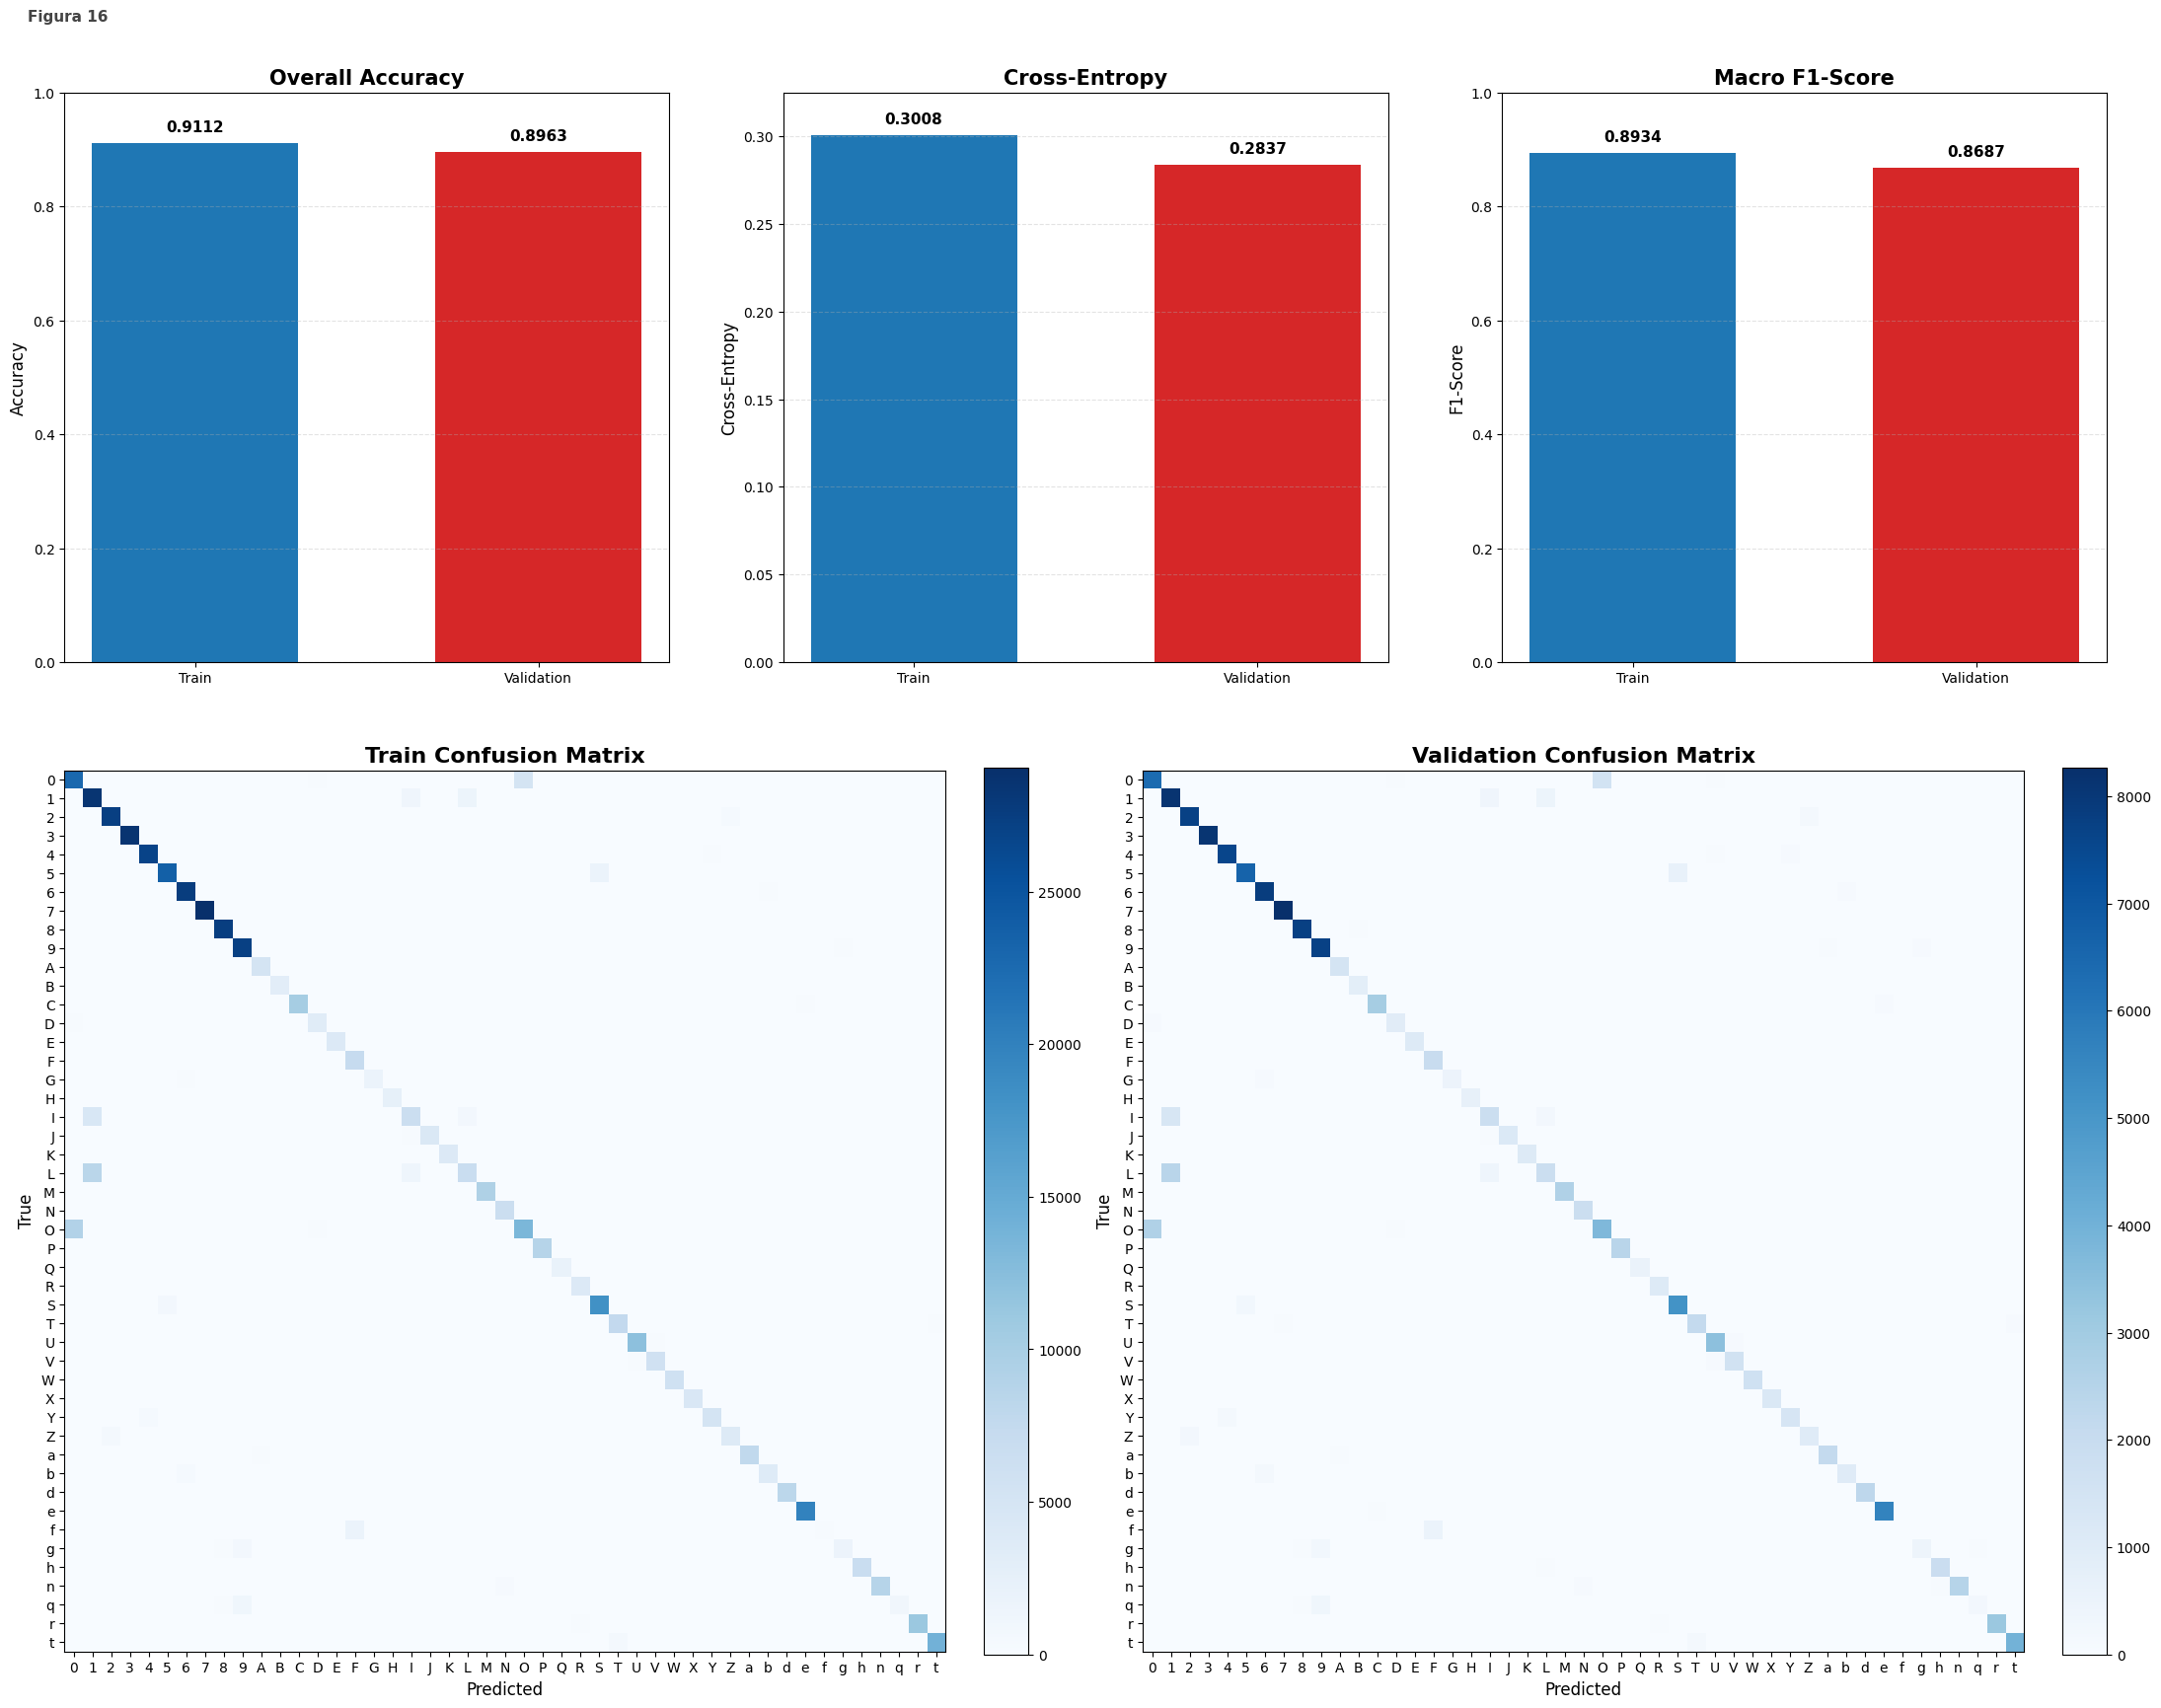

In [58]:
evaluate_model(
    m3, 
    X_train_tensor.detach().cpu().numpy(), 
    y_train_tensor.detach().cpu().numpy(), 
    X_val_tensor.detach().cpu().numpy(), 
    y_val_tensor.detach().cpu().numpy(),
    device=device, 
    fig_num=fig_num
)

In [59]:
del X_train_tensor
del y_train_tensor
del X_val_tensor
del y_val_tensor

<h3 style="color: #00B0FF; font-weight: 400">
    Performance de los modelos con respecto a test
</h3>

Primero entreno todos los modelos usando **DEV** con la cantidad de epochs que entrenó para la partición train / val y luego evalúo en todo **TEST**



In [60]:
X_dev_tensor = torch.from_numpy(X_dev).float().to(device)
y_dev_tensor = torch.from_numpy(y_dev).long().to(device)

dev_dataset = TensorDataset(X_dev_tensor, y_dev_tensor)

**M0**

In [61]:
m0_test.fit(X_dev, y_dev, last_epoch_m0, batch_size=None)

y_pred_m0 = m0_test.predict(X_test)

Training: 100%|██████████| 298/298 [31:07<00:00,  6.27s/ep]


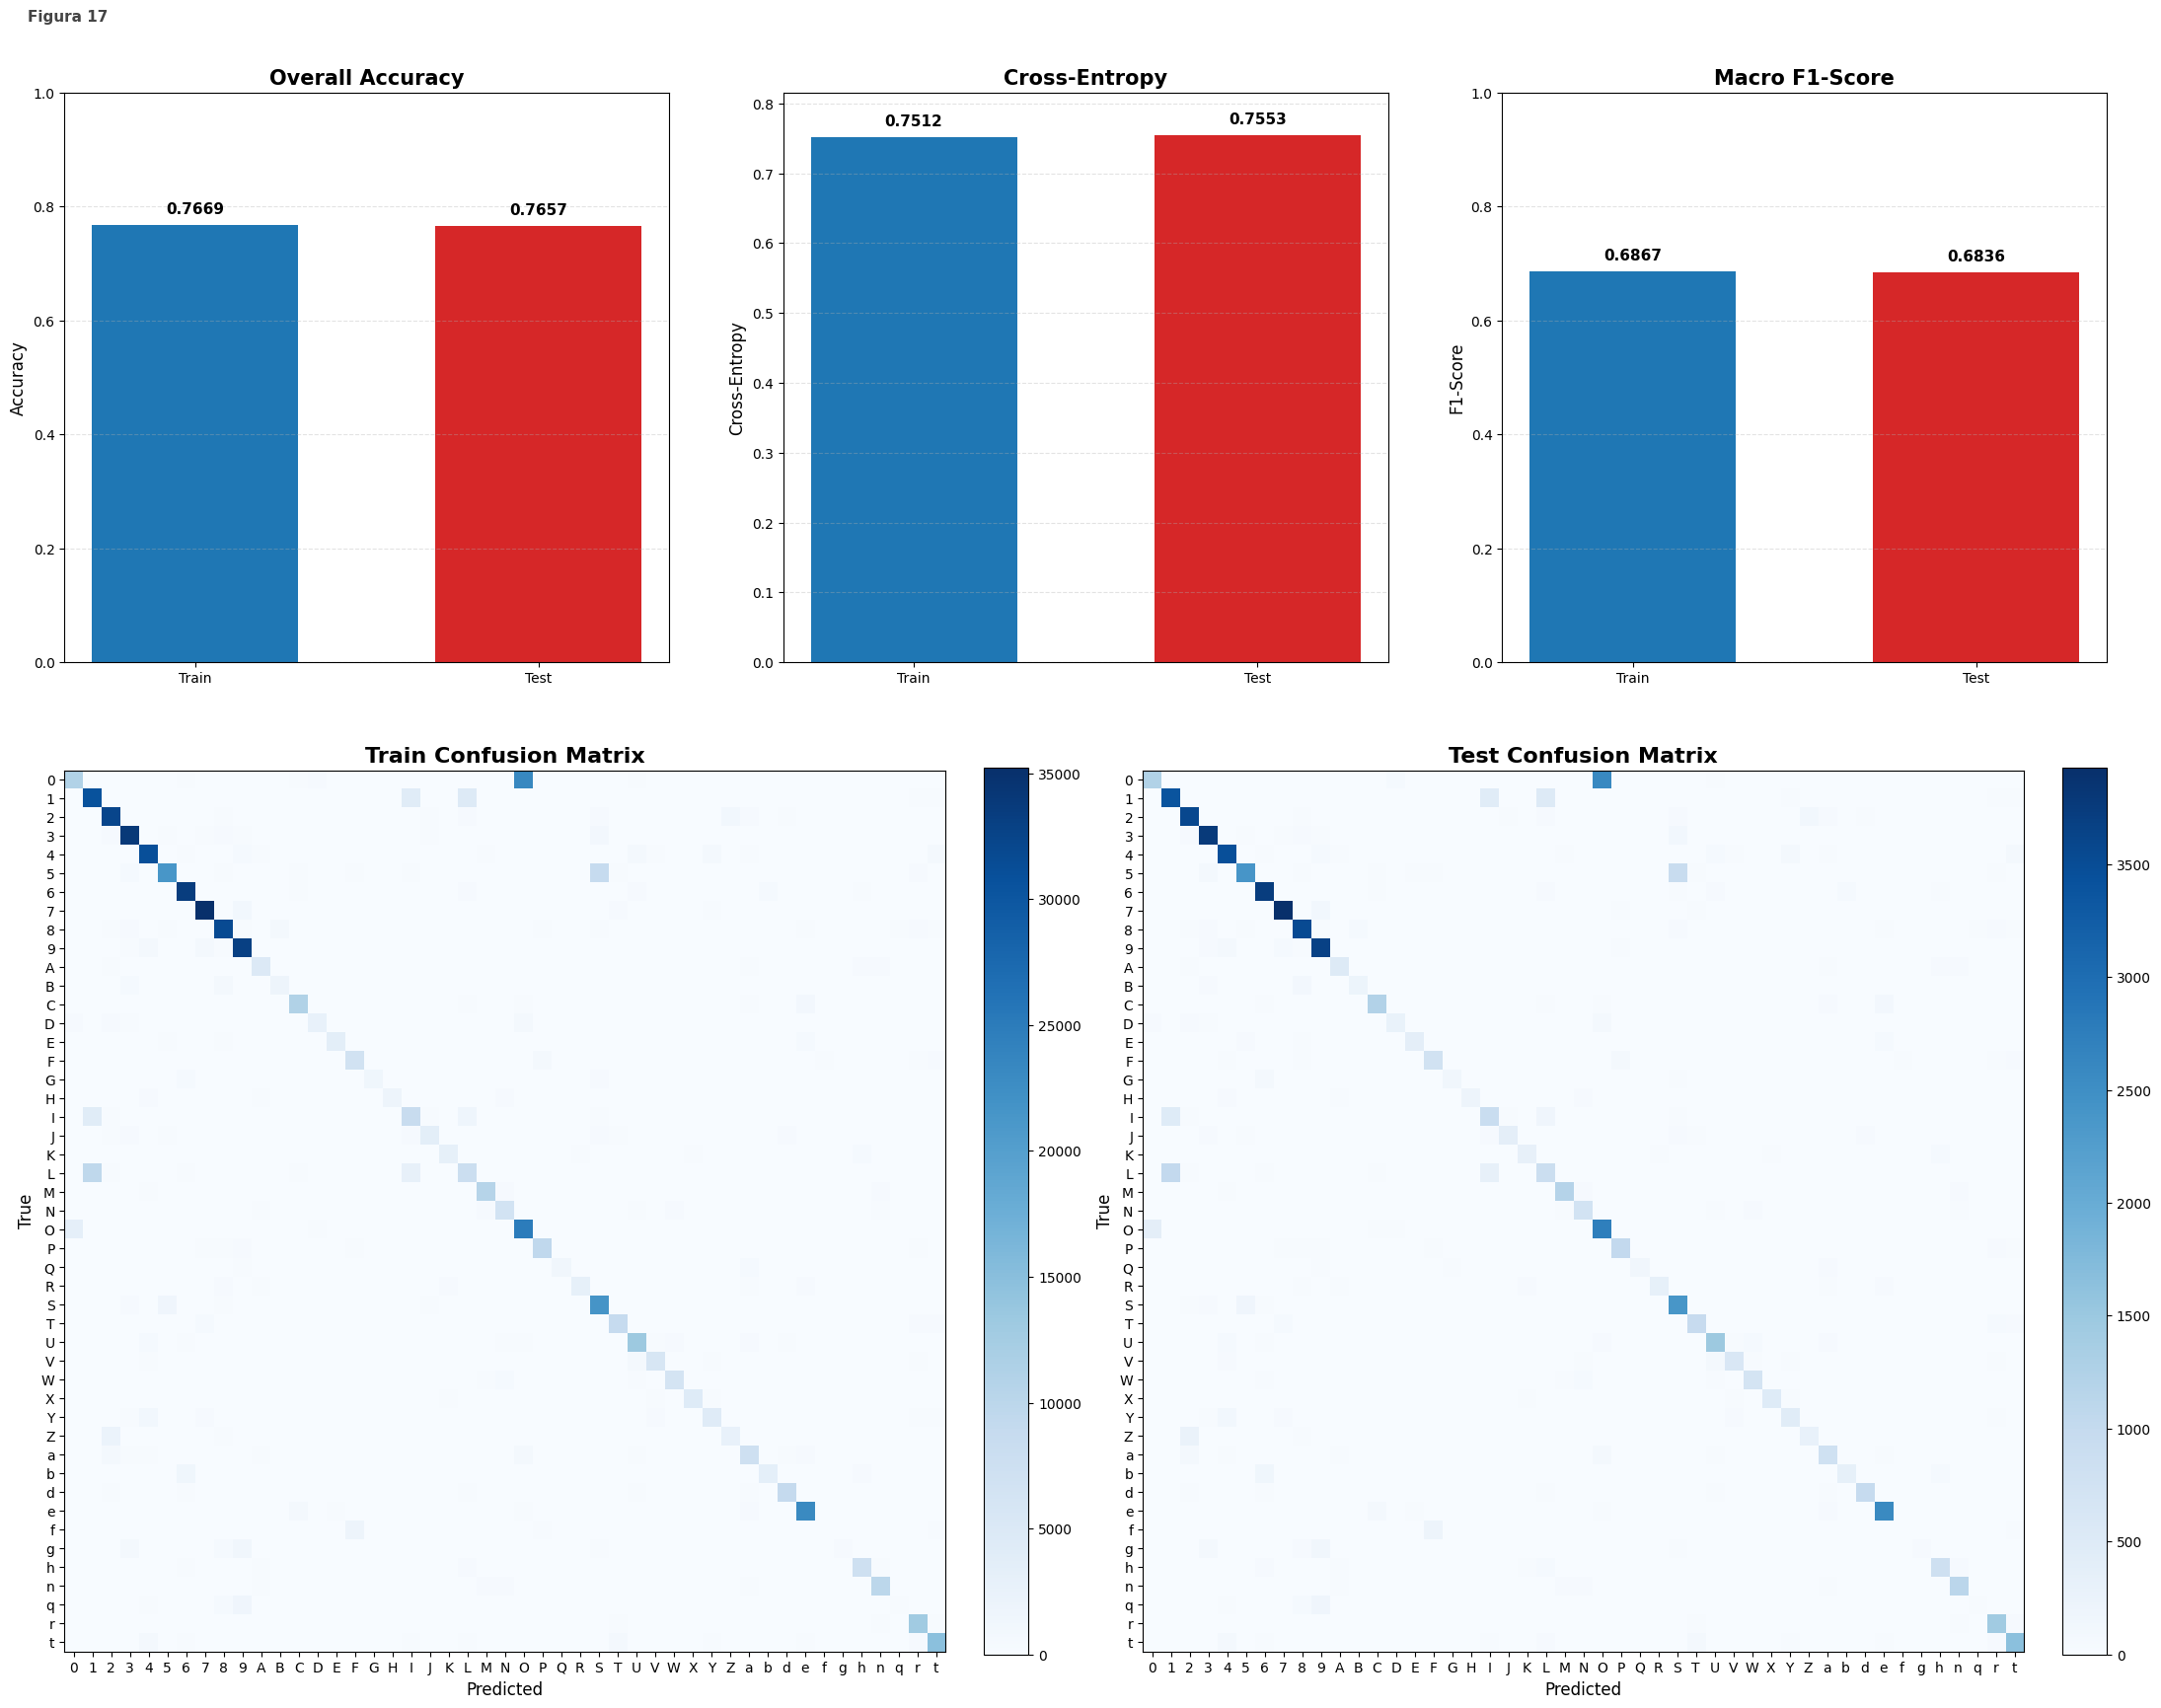

In [62]:
evaluate_model(m0_test, X_dev, y_dev, X_test, y_test, val_name="Test", fig_num=fig_num)

**M1**

In [63]:
m1_test.fit(X_dev, y_dev, last_epoch_m1, config_m1["batch_size"])

y_pred_m1 = m1_test.predict(X_test)

Training: 100%|██████████| 9/9 [01:20<00:00,  8.97s/ep]


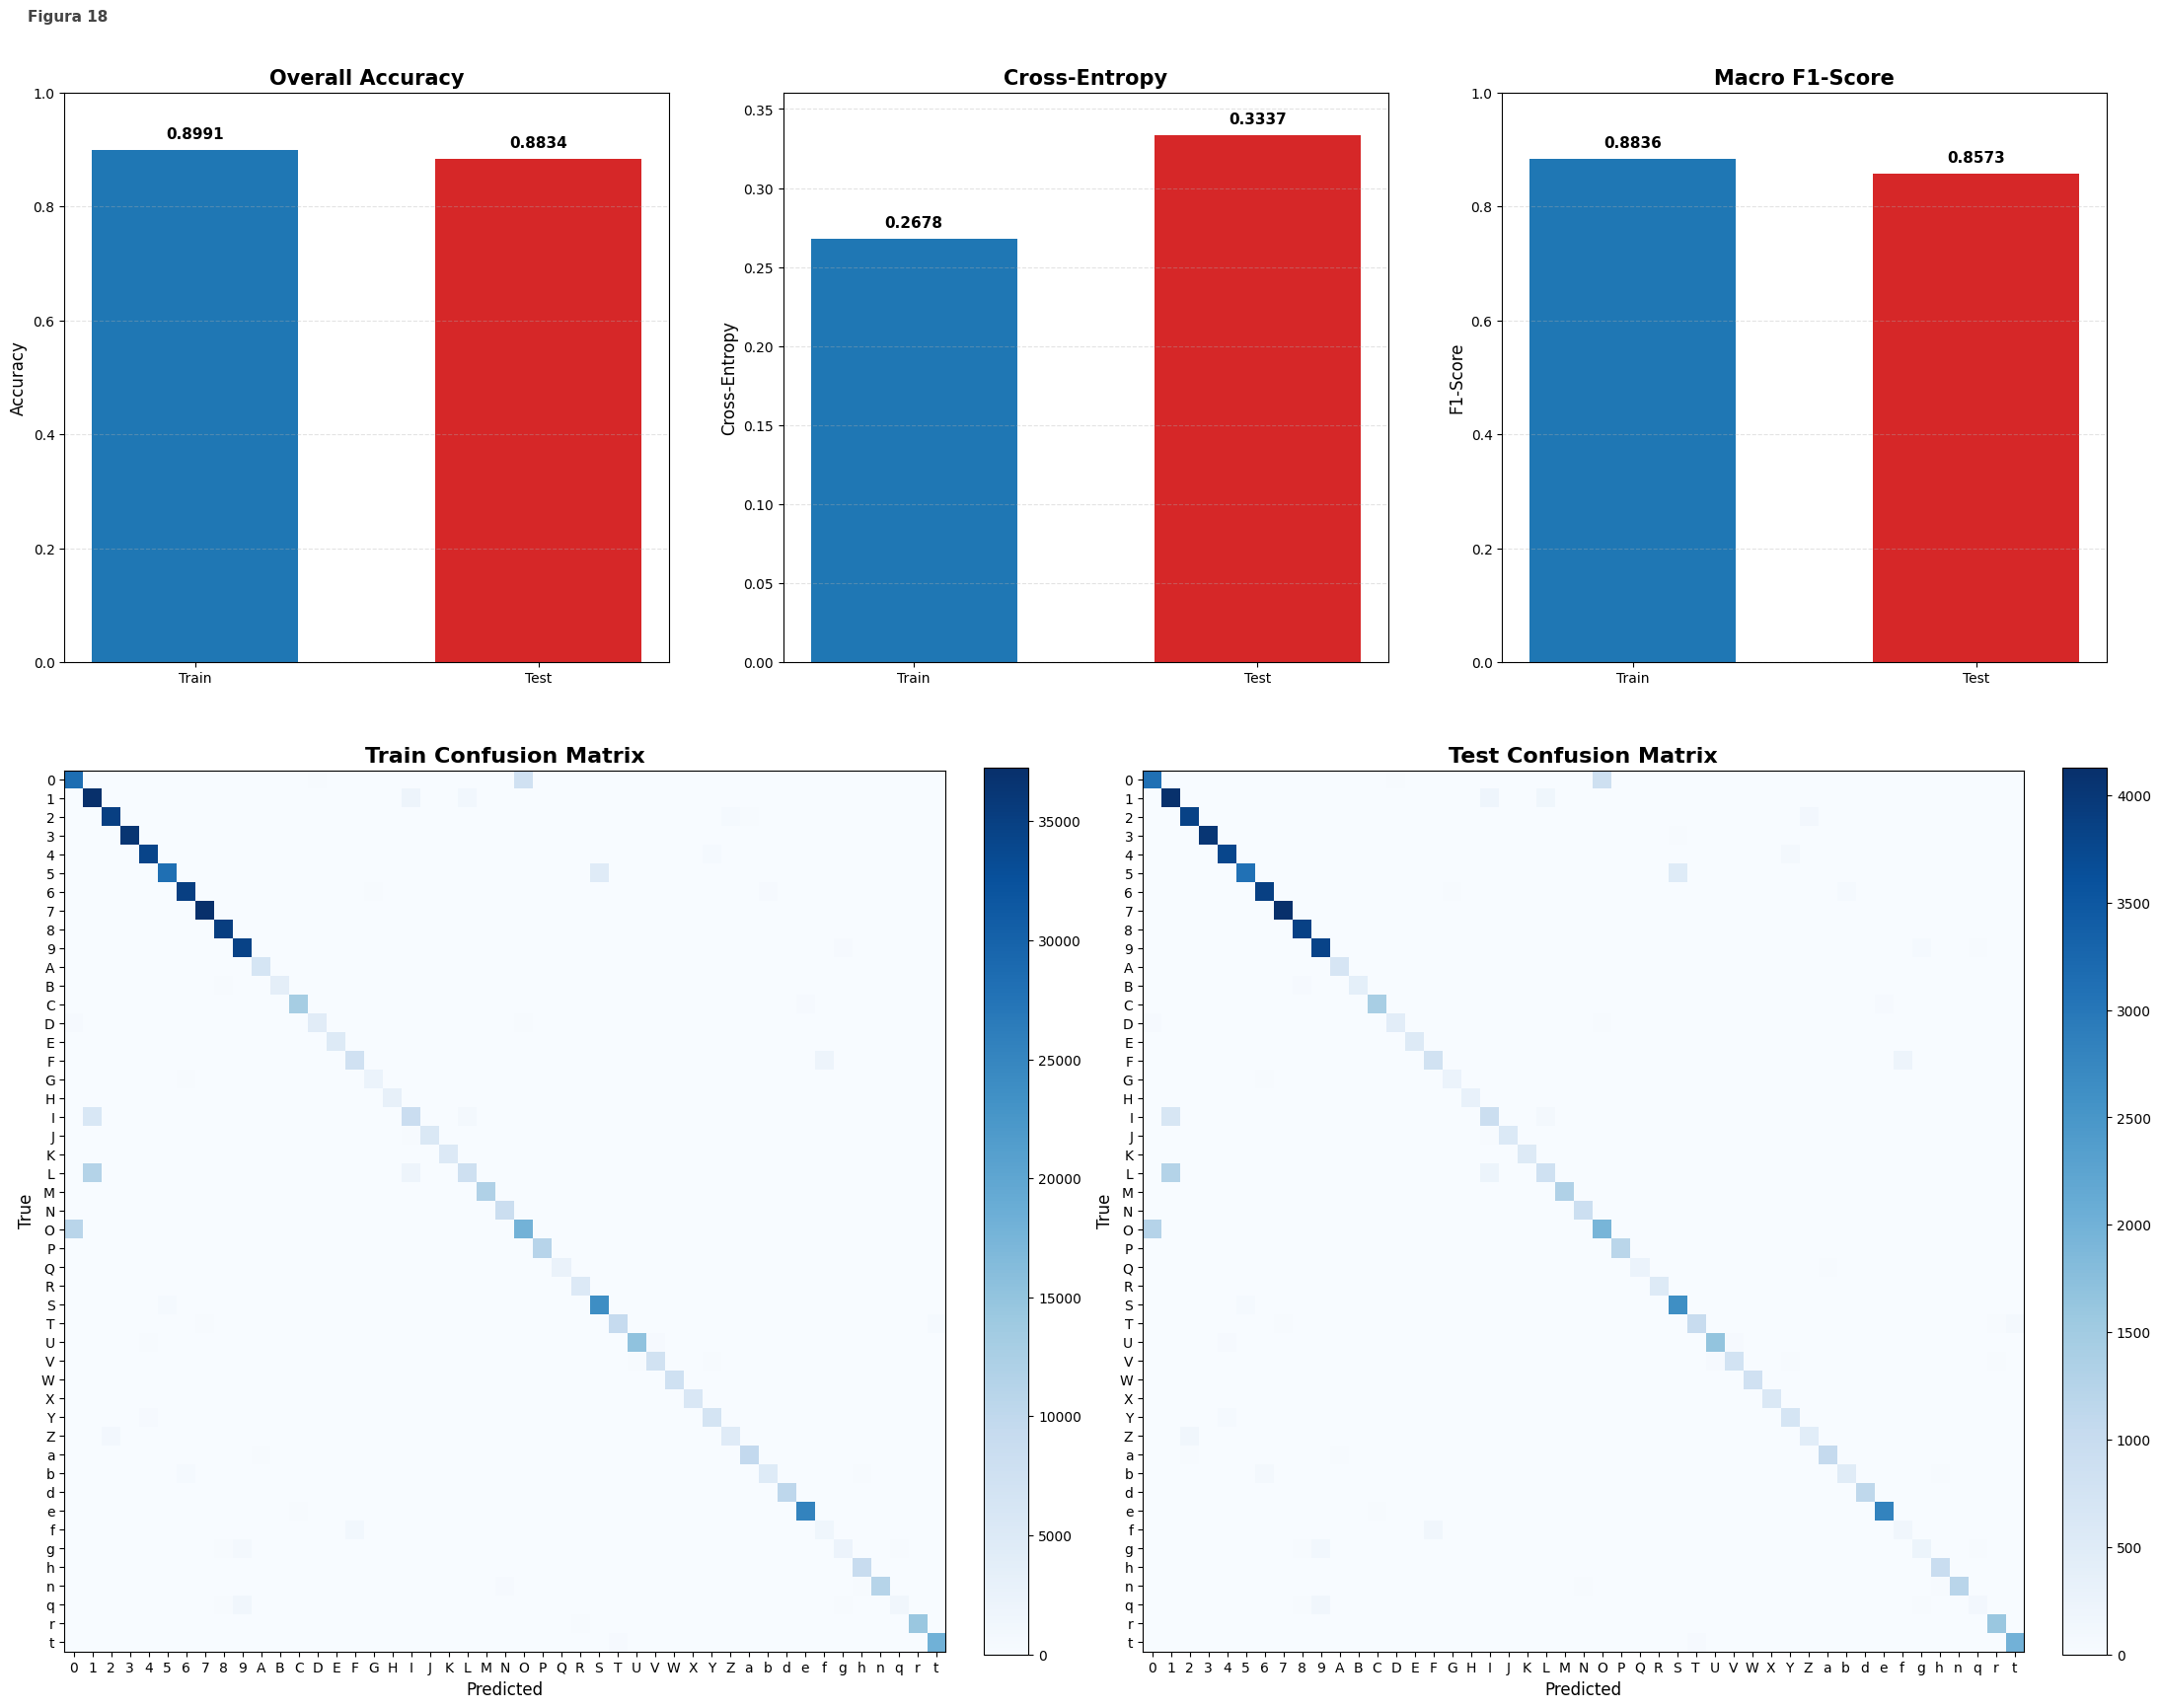

In [64]:
evaluate_model(m1_test, X_dev, y_dev, X_test, y_test, val_name="Test", fig_num=fig_num)

**M2**

In [65]:
X_test_tensor = torch.from_numpy(X_test).float().to(device)

dev_loader_m2 = DataLoader(
    dev_dataset,
    batch_size=config_m2["batch_size"],
    shuffle=True,
    drop_last=True
)

m2_test.to(device)

optimizer_m2_test = torch.optim.Adam(m2_test.parameters(), lr=config_m2["lr"], weight_decay=config_m2["l2"])

scheduler_m2_test = get_scheduler(config_m2["scheduling"], optimizer_m2_test)

for t in tqdm(range(last_epoch_m2)):
    train_loop(dev_loader_m2, m2_test, nn.CrossEntropyLoss(label_smoothing=config_m2["label_smoothing"]), optimizer_m2_test, device)
    
    if scheduler_m2_test is not None:
        scheduler_m2_test.step()
    
y_pred_m2 = get_predictions(m2_test, X_test, device)

100%|██████████| 8/8 [02:14<00:00, 16.83s/it]


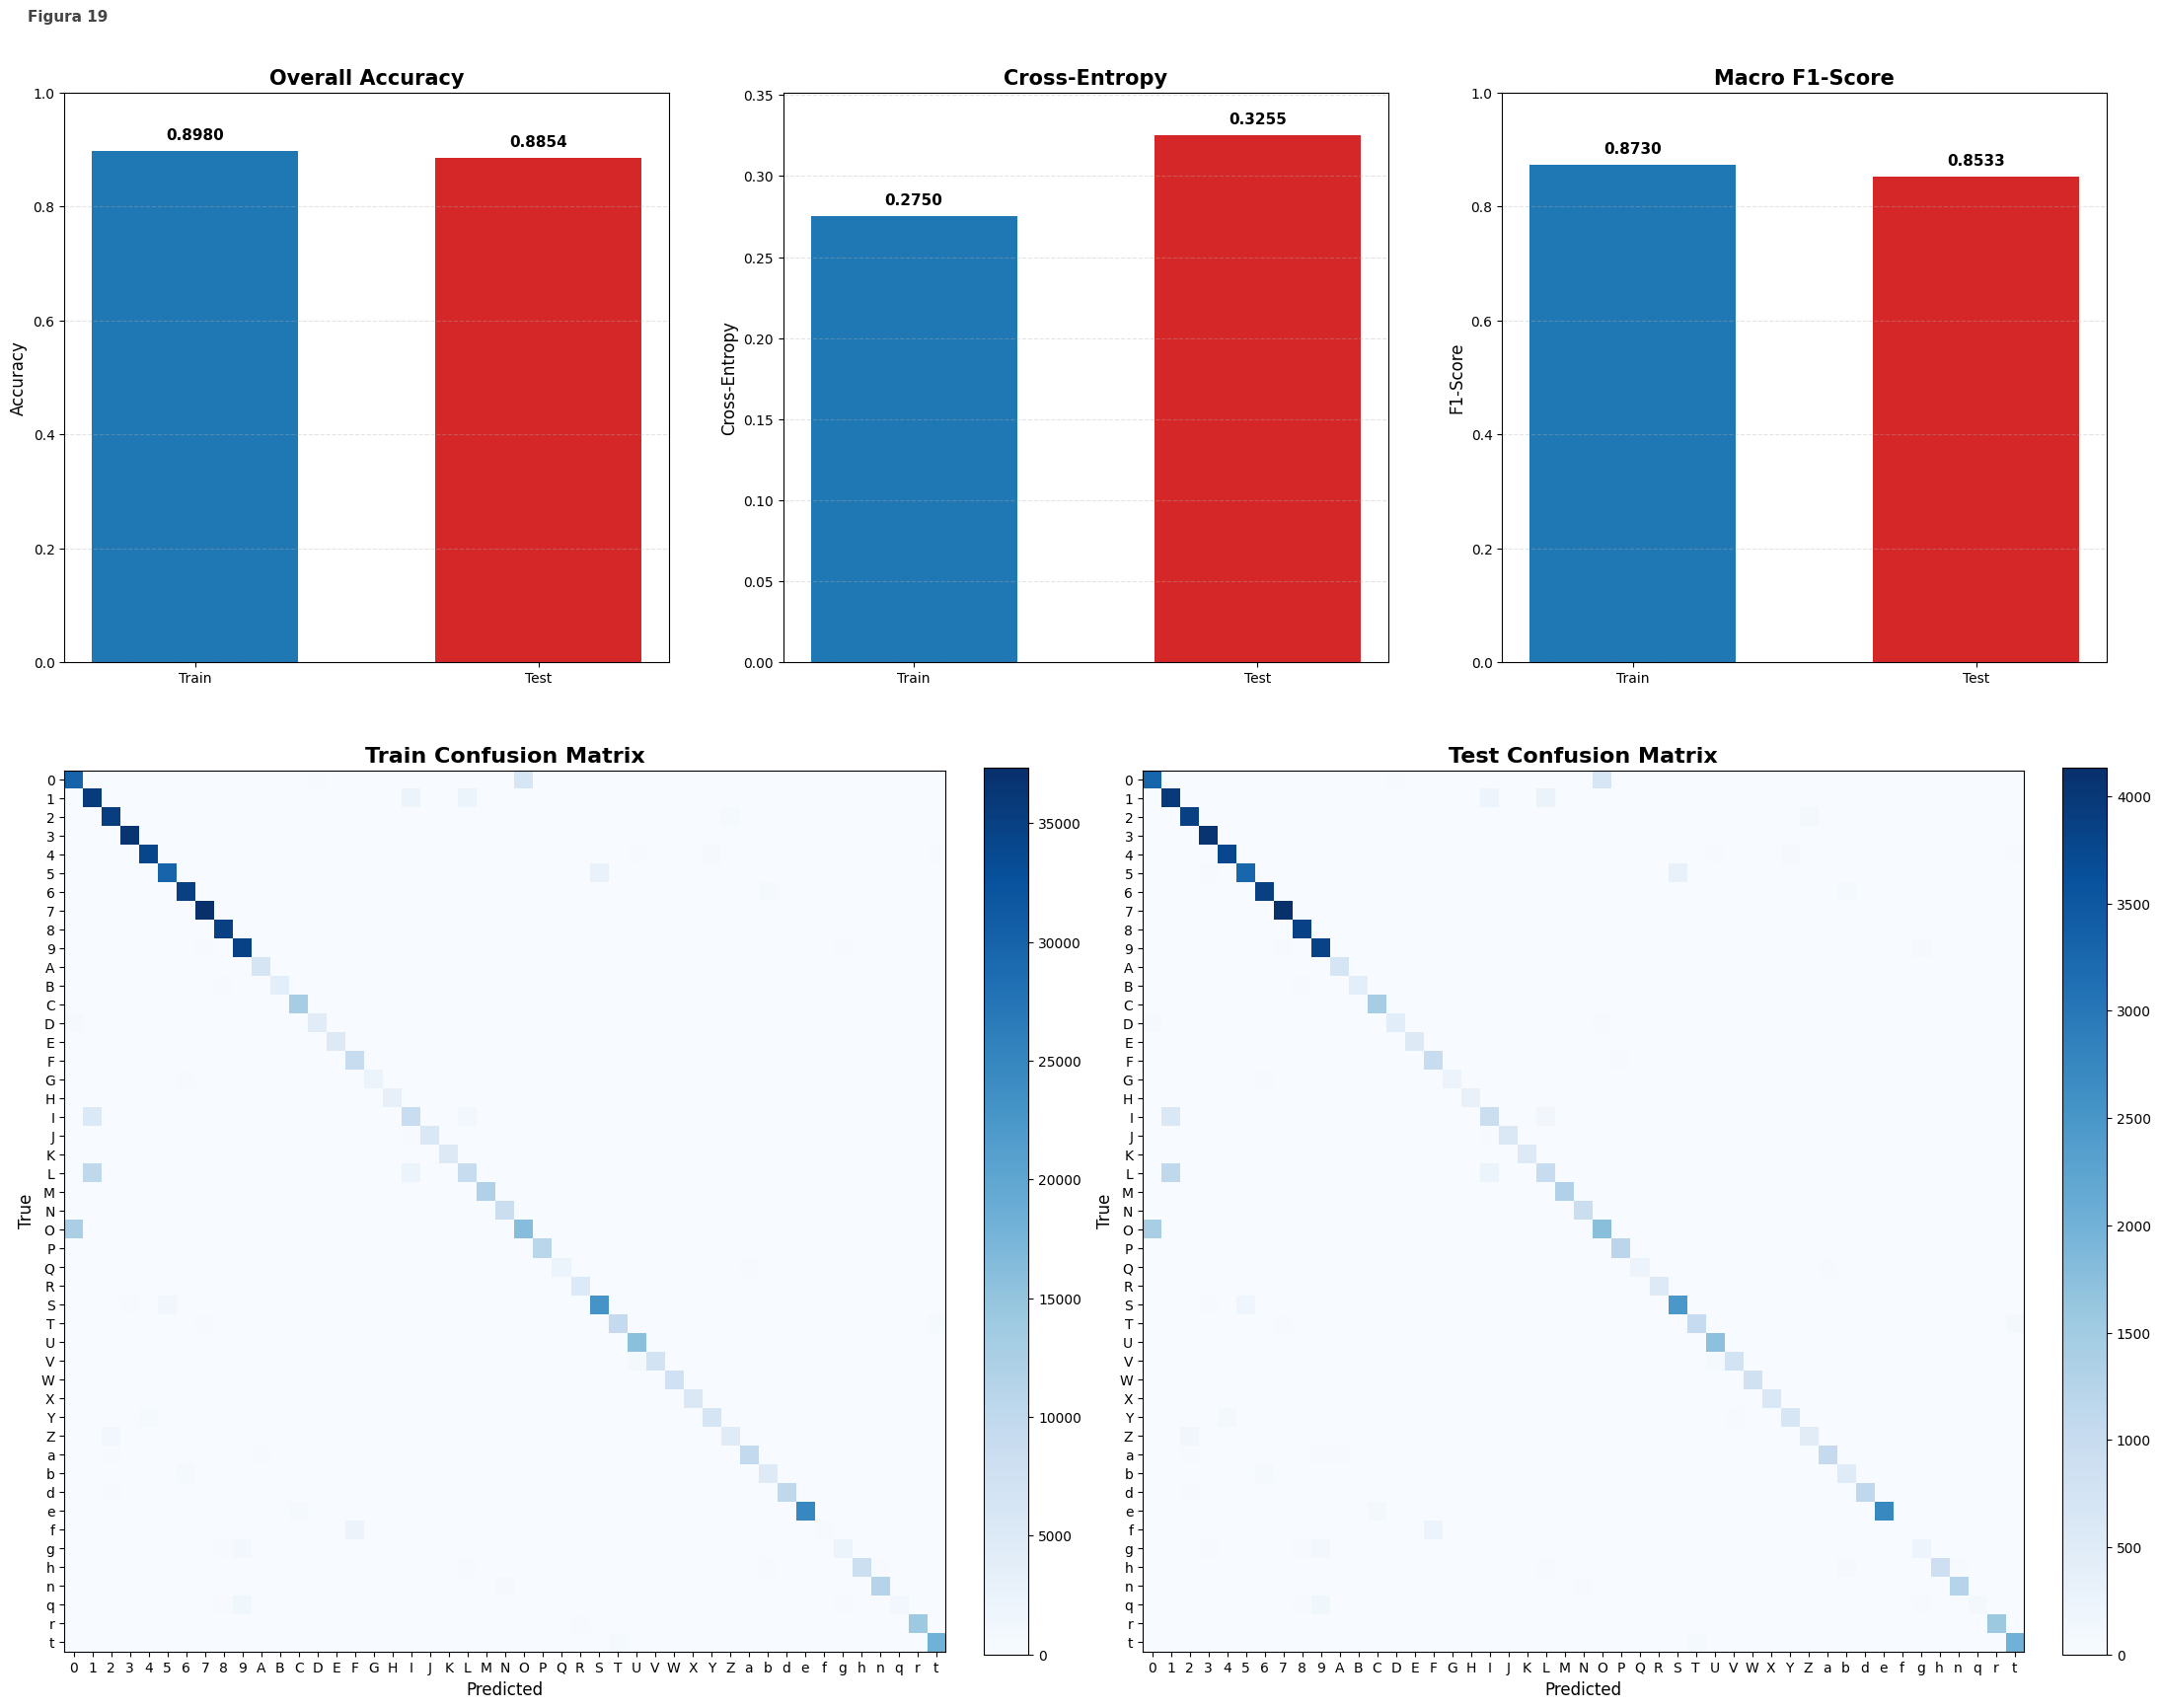

In [66]:
evaluate_model(m2_test, X_dev, y_dev, X_test, y_test, val_name="Test", device=device, fig_num=fig_num)

**M3**

In [67]:
dev_loader_m3 = DataLoader(
    dev_dataset,
    batch_size=config_m3["batch_size"],
    shuffle=True,
    drop_last=True
)

m3_test.to(device)

optimizer_m3_test = config_m3["optimizer"](m3_test.parameters(), lr=config_m3["lr"], weight_decay=config_m3["l2"])

scheduler_m3_test = get_scheduler(config_m3["scheduling"], optimizer_m3_test)

for t in tqdm(range(last_epoch_m3)):
    train_loop(dev_loader_m3, m3_test, nn.CrossEntropyLoss(label_smoothing=config_m3["label_smoothing"]), optimizer_m3_test, device)
    
    if scheduler_m3_test is not None:
        scheduler_m3_test.step()
    
y_pred_m3 = get_predictions(m3_test, X_test, device)

100%|██████████| 23/23 [07:12<00:00, 18.82s/it]


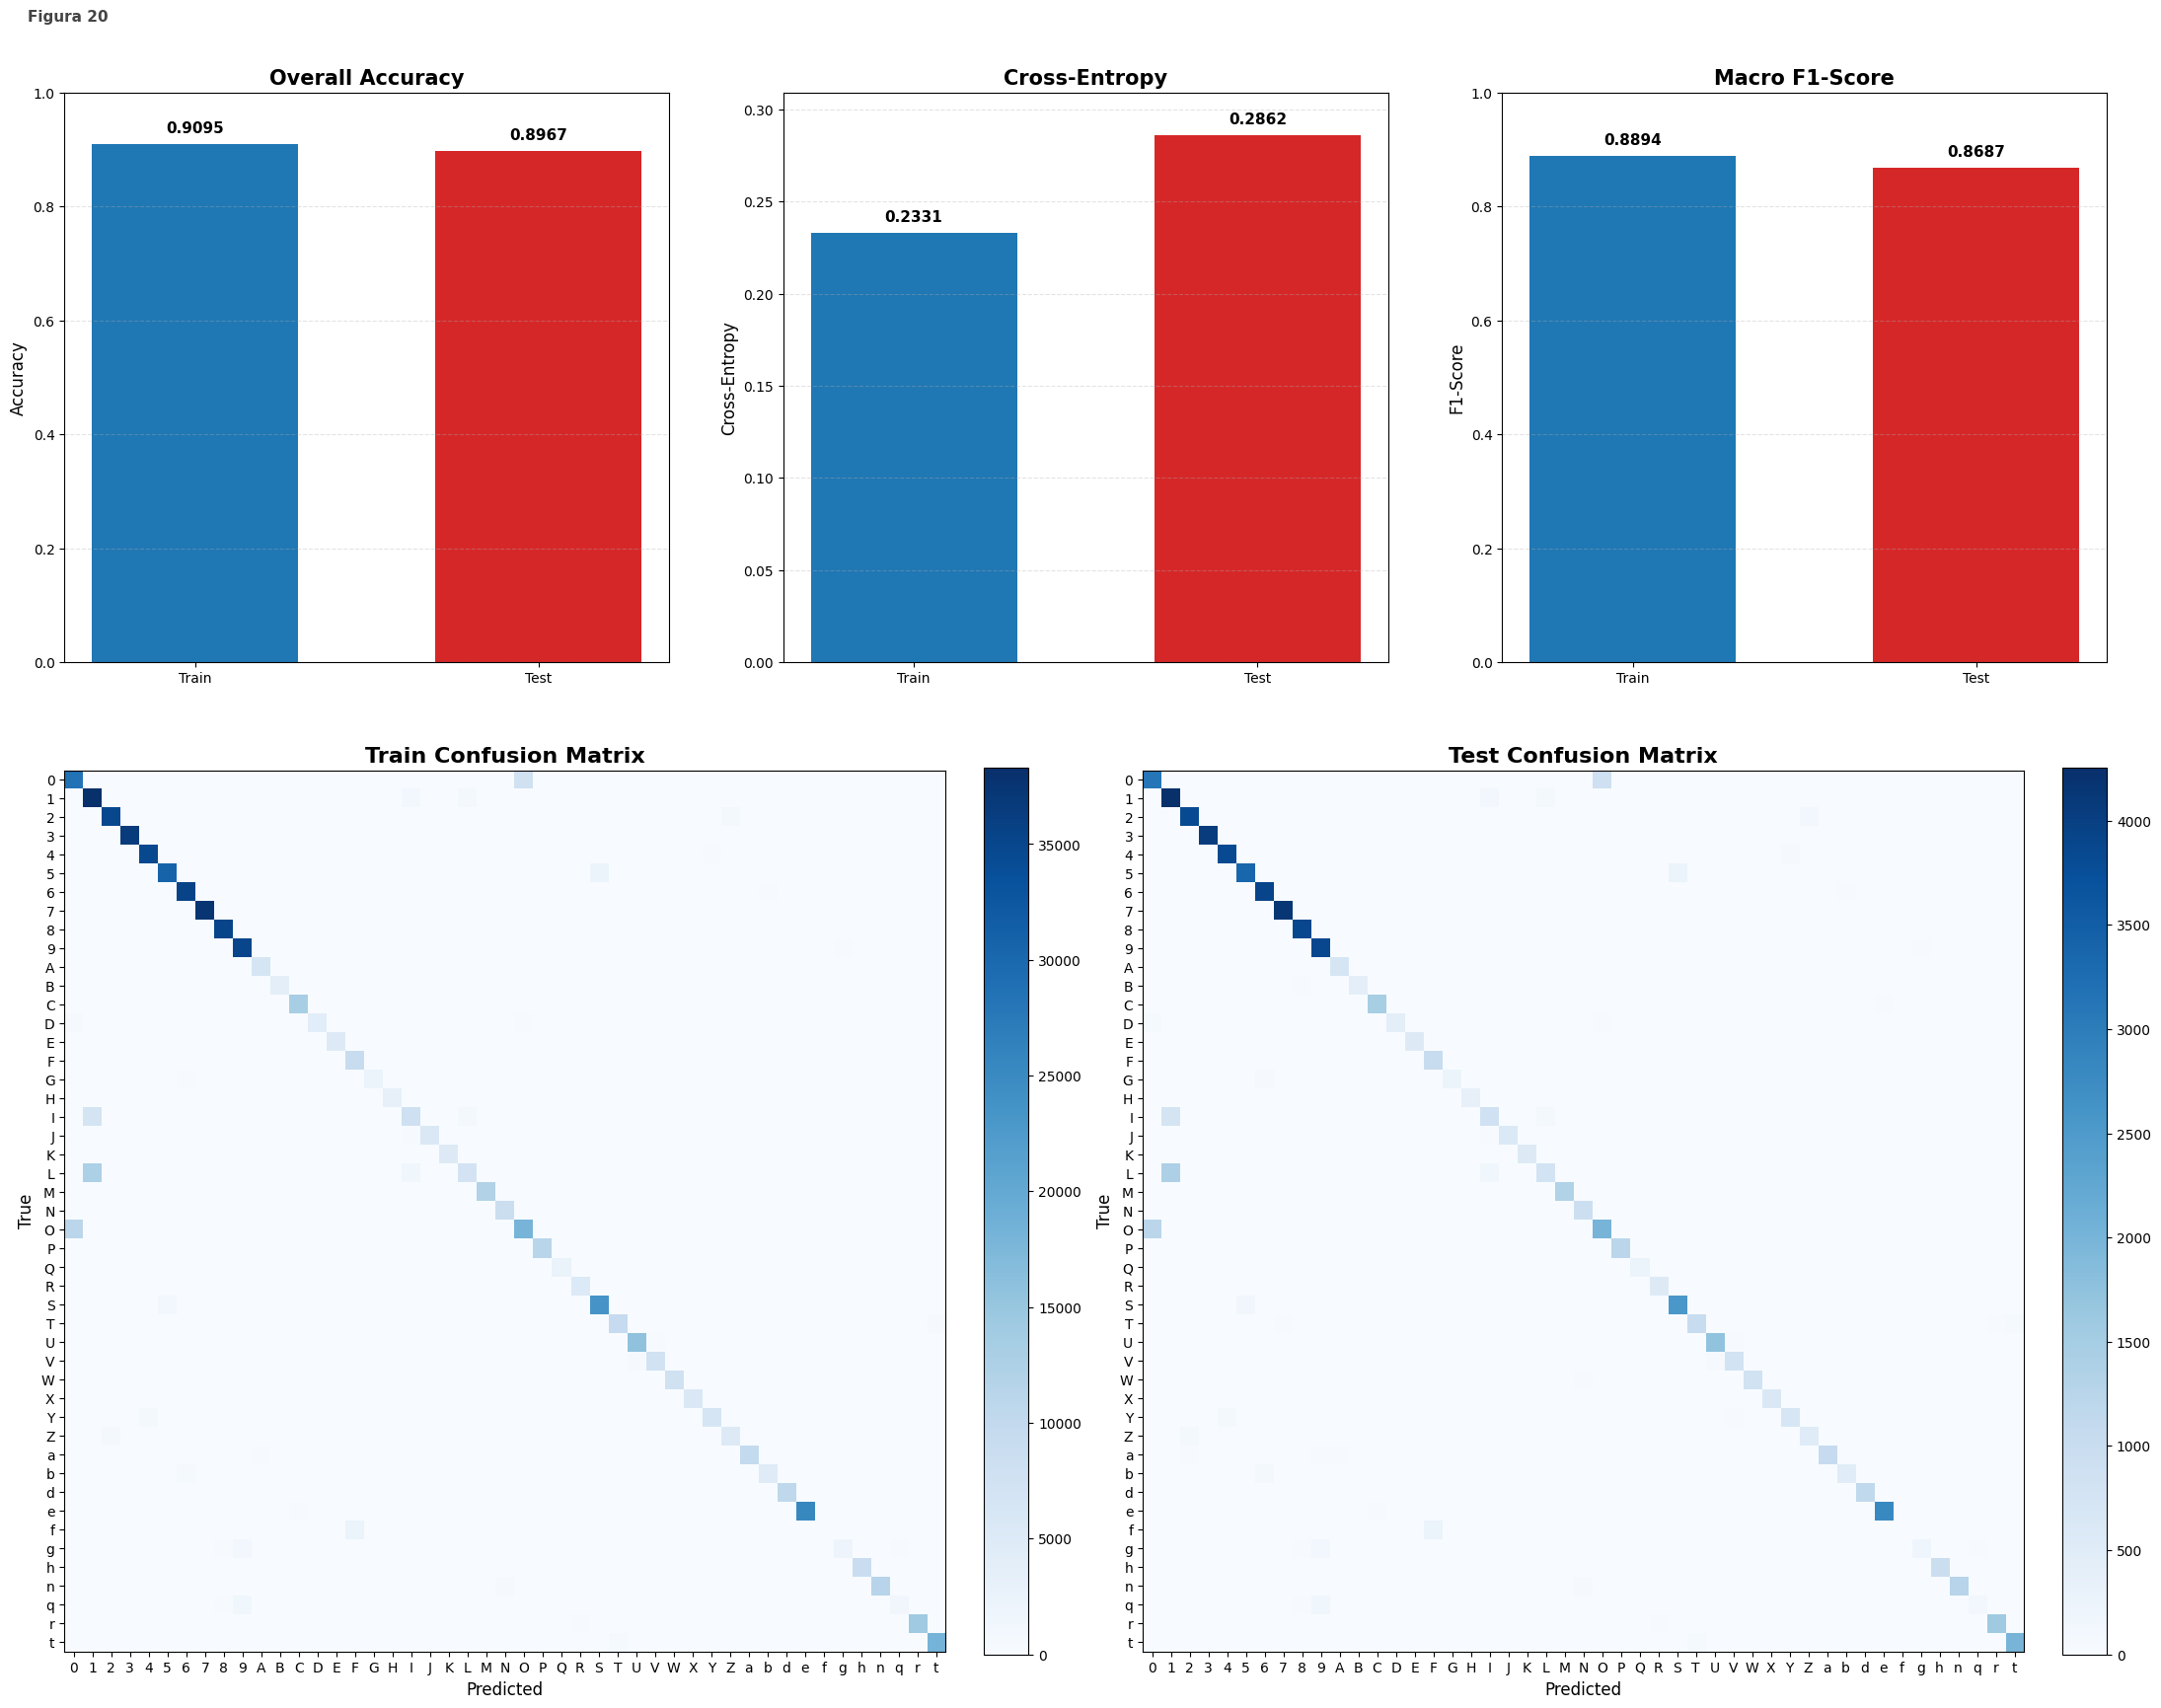

In [68]:
evaluate_model(m3_test, X_dev, y_dev, X_test, y_test, val_name="Test", device=device, fig_num=fig_num)

**Gráfico comparativo**

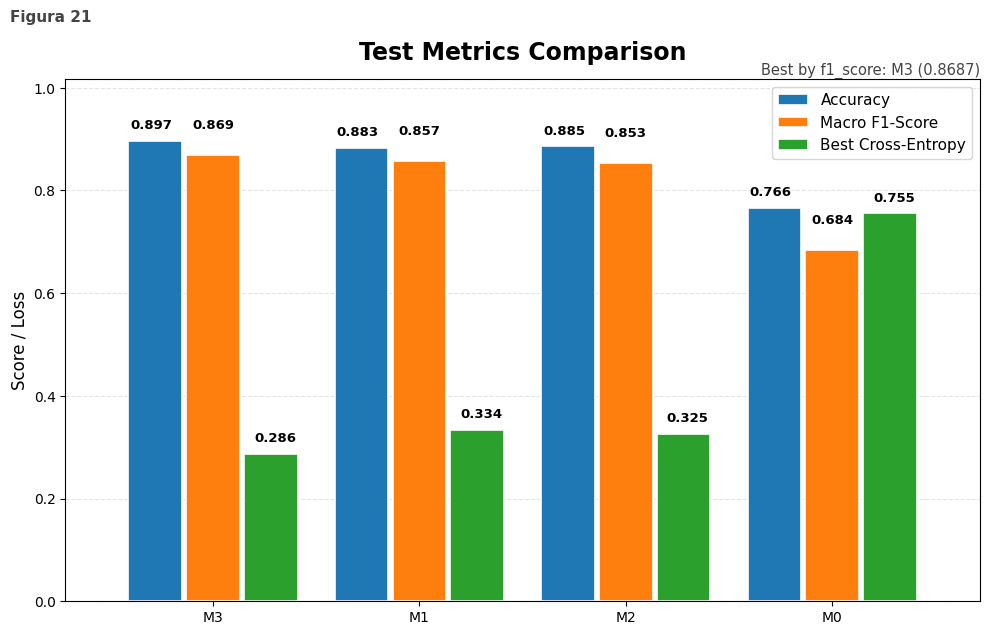

In [69]:
models = {"M0": m0_test, "M1": m1_test, "M2": m2_test, "M3": m3_test}

plot_model_metric_comparison(models, X_test, y_test, device=device, fig_num=fig_num)

En términos de desempeño sobre el conjunto de test, los modelos implementados con PyTorch superaron claramente a las versiones custom. En particular, M3 fue el mejor modelo, con accuracy y macro-F1 más altos, seguido por M2 y M1 . En cambio, M0 quedó bastante por debajo, lo que se debe a que es el modelo con la arquitectura más básico que sirve como baseline. Que el F1 haya sido menor que el accuracy para todos los modelos indica que hay clases más difíciles de predecir que otras. Esto se puede observar en las matrices de confusión de los modelos, ya que por ejemplo, todos los modelos confunden 'O' con '0', 'L' con '1', 'I' con '1' y 'S' con '5', entre otras. Esto era algo esperable por la similaridad de los caracteres.

**Robustez de los modelos**

In [70]:
noise_levels = [0.1, 0.2, 0.3]

df = evaluate_noise_robustness(models, X_test, y_test, noise_levels, device)

display(df.style.hide(axis="index").format({"noise_level": "{:.1f}"}))

model,noise_level,accuracy,f1_score
M0,0.0,0.765702,0.683554
M0,0.1,0.755020,0.671942
M0,0.2,0.709403,0.630726
M0,0.3,0.625590,0.546422
M1,0.0,0.883425,0.857298
M1,0.1,0.743881,0.688233
M1,0.2,0.377201,0.363501
M1,0.3,0.151337,0.150747
M2,0.0,0.885426,0.853251
M2,0.1,0.732075,0.668558


El análisis de robustez muestra que los modelos presentan comportamientos distintos frente a perturbaciones en los datos de test. Sobre datos sin ruido y con leve ruido (noise = 0.1), **M3** obtiene el mejor desempeño general (accuracy $\approx$ 0.897, macro-F1 $\approx$ 0.869 y accuracy $\approx$ 0.827, macro-F1 $\approx$ 0.775), seguido muy de cerca por **M1** y **M2**.

Para niveles de ruido mayores (0.2 y 0.3), el **M0** muestra el mejor desempeño, mientras que **M3** presenta una caída abrupta en desempeño, alcanzando valores cercanos al azar bajo perturbaciones fuertes junto con el **M1** y **M2**.

Esto sugiere que **M3** maximiza performance en condiciones ideales y con ruido leve, mientras que el **M0** tiene la mejor performance para niveles de ruido elevados.

---

**Modelo elegido para producción**

El modelo elegido para llevar a producción es el **M3**. Si bien no es el modelo más robusto frente a ruido, es el que alcanza el mejor desempeño global sobre datos limpios de test y con ruido leve, que representan el objetivo principal.

Además, está implementado en PyTorch, lo que asegura reproducibilidad y aceleración por GPU. El **M3** incorpora la mayor cantidad de mejoras y estructuras, y optimizaciones exploradas durante el desarrollo.